<h1 align=center > Analysing and Predicting Insurance Claim </h1>

In [1]:
# import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.svm import SVR

In [2]:
df = pd.read_csv('data/insurance_data.csv')
df.sample(5)

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
361,361,362,27.0,female,26.7,99,No,1,No,southeast,5002.78
1159,1159,1160,30.0,female,31.9,87,Yes,3,No,southeast,27322.73
894,894,895,38.0,male,17.3,82,Yes,2,Yes,northeast,12829.46
230,230,231,22.0,male,30.4,95,Yes,3,No,southeast,3481.87
753,753,754,38.0,female,28.2,86,No,3,No,southeast,10702.64


### Dimension of data

In [3]:
df.shape

(1340, 11)

### How Many Null Values

In [4]:
df.isnull().sum()

index            0
PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

> **Observation:** **Age** has 5 and **region** has 3 null values 

### What type of data is?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


### Data Cleaning

In [6]:
df.drop(columns=['index','PatientID'],inplace=True)
df.sample(5)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1123,60.0,female,30.6,85,No,2,No,northwest,24059.68
860,37.0,female,33.4,84,Yes,0,No,northwest,12231.61
863,27.0,female,35.2,83,Yes,0,No,southeast,12244.53
886,31.0,female,33.8,86,Yes,2,No,northwest,12643.38
370,55.0,female,38.8,86,No,3,No,southeast,5138.26


### Separate out Categorical and Numerical Features

In [7]:
cat_cols = df.select_dtypes(exclude=np.number).columns.to_list()
print("Categorical columns : ", cat_cols)

Categorical columns :  ['gender', 'diabetic', 'smoker', 'region']


In [8]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
print("Numerical columns : ", num_cols)

Numerical columns :  ['age', 'bmi', 'bloodpressure', 'children', 'claim']


In [9]:
df['age'].describe()

count    1335.000000
mean       38.078652
std        11.102924
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

In [22]:
sns.set_context('paper', font_scale = 2)
sns.set_style('darkgrid')

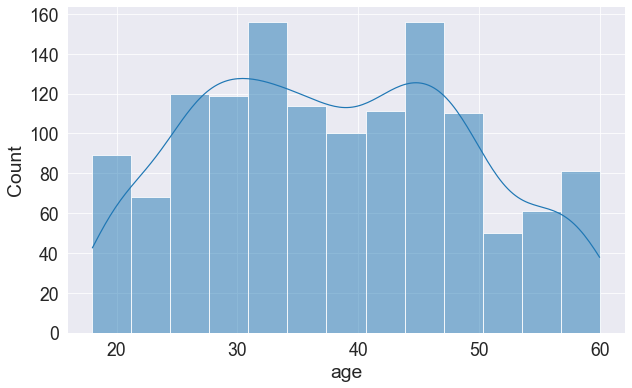

In [23]:
plt.rcParams['figure.figsize'] = (10, 6)
sns.histplot(df['age'],kde=True);

> - ###   Appears Almost binomial, with peaks around 30-35 and 40-45.

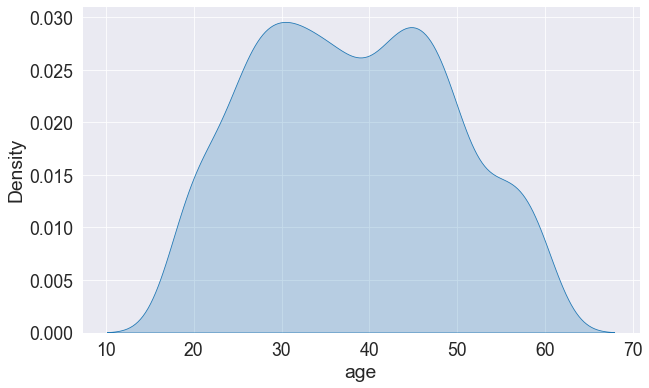

In [24]:
sns.kdeplot(df['age'],fill=True);

In [25]:
df['age'].skew()

0.11361133741072633

In [26]:
df.isnull().sum()

age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [27]:
df['age'].isnull().sum()

5

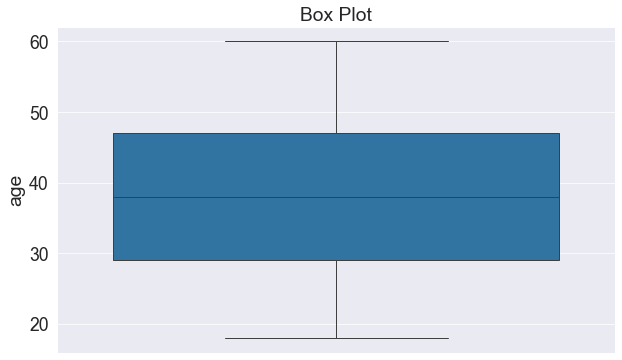

In [28]:
sns.boxplot(df['age'])
plt.title('Box Plot');

In [29]:
cat_df = pd.DataFrame()

In [30]:
df['bmi'].describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

In [3]:
sns.boxplot(df['bmi'])
plt.title('Box Plot');

NameError: name 'df' is not defined

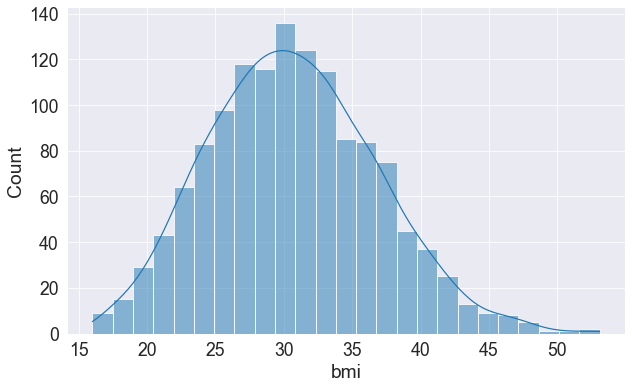

In [31]:
sns.histplot(df['bmi'],kde=True);

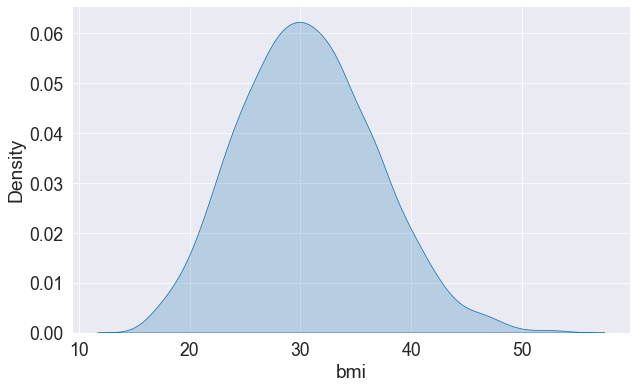

In [32]:
sns.kdeplot(df['bmi'],fill=True);

> ###  **Observation:** Normally Distributed

### Outliers Detection

In [33]:
upper_limit= df['bmi'].mean()+3*df['bmi'].std()
upper_limit

48.989159524406574

In [34]:
tmp_bmi = df['bmi']

In [35]:
df[df['bmi']>upper_limit].shape

(4, 9)

>  There are 4 outliers in BMI

### Removing Outliers 

In [36]:
df['bmi']= np.where(df['bmi'] >upper_limit,upper_limit,df['bmi'])

In [37]:
df[df['bmi']>upper_limit].shape

(0, 9)

> - #### Outliers have removed

In [38]:
def bmi_categorizer(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 24.9:
        return "Healthy"
    elif 25 <= bmi < 29.9:
        return "Overweight"
    elif bmi >= 30 and bmi < 40:
        return "Obese"
    else:
        return "Very Obese"

cat_df['bmi'] = df['bmi'].apply(bmi_categorizer)

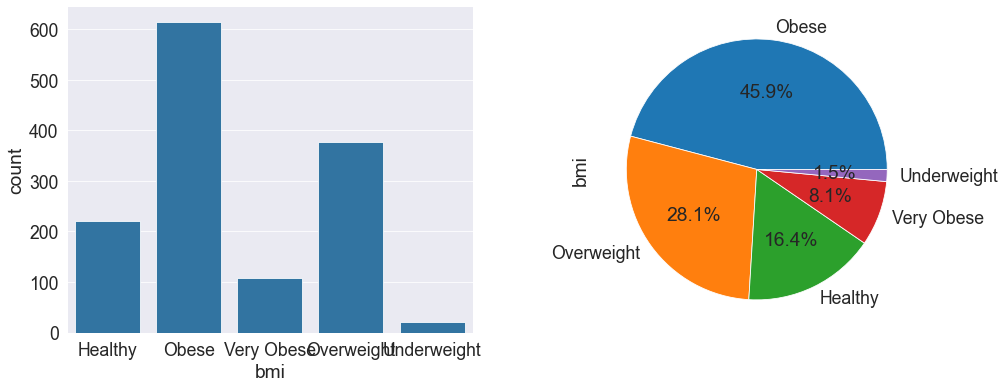

In [39]:
fig = plt.figure(figsize=(16,6))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=cat_df['bmi'],ax=ax1)
cat_df['bmi'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2);

> **BMI Observations**
> - Normally distributed with 4 outliers.
> - Predominantly obese patients and very few underweight individuals.

### Blood Pressure

- **Missing Values**     0 
- **Shape** Highly Positive Skewed
- **Outliers** 4.6 % Outliers 

In [40]:
df['bloodpressure'].describe()

count    1340.000000
mean       94.157463
std        11.434712
min        80.000000
25%        86.000000
50%        92.000000
75%        99.000000
max       140.000000
Name: bloodpressure, dtype: float64

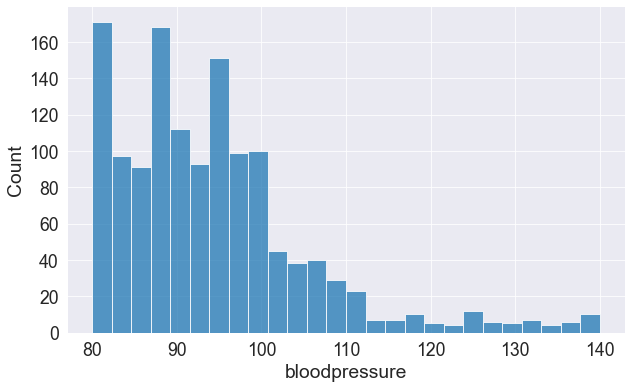

In [41]:
sns.histplot(df['bloodpressure']);

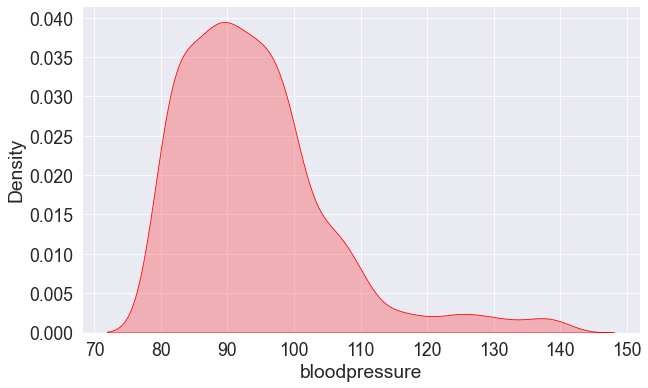

In [42]:
sns.kdeplot(df['bloodpressure'], fill=True, color='red, cbar=True);

In [43]:
df['bmi'].max()

48.989159524406574

In [44]:
df['bloodpressure'].skew()

1.4835342102293079

In [45]:
def bp_categorizer(bp):
    if 80<=bp < 89:
        return "elevated"
    elif 90<= bp <= 99:
        return "High"
    elif  99< bp <100:
        return "very high"
    elif 100<=bp<120:
        return "extremely high"
    else:
        return "fatal"

cat_df['bloodpressure'] = df['bloodpressure'].apply(bp_categorizer)

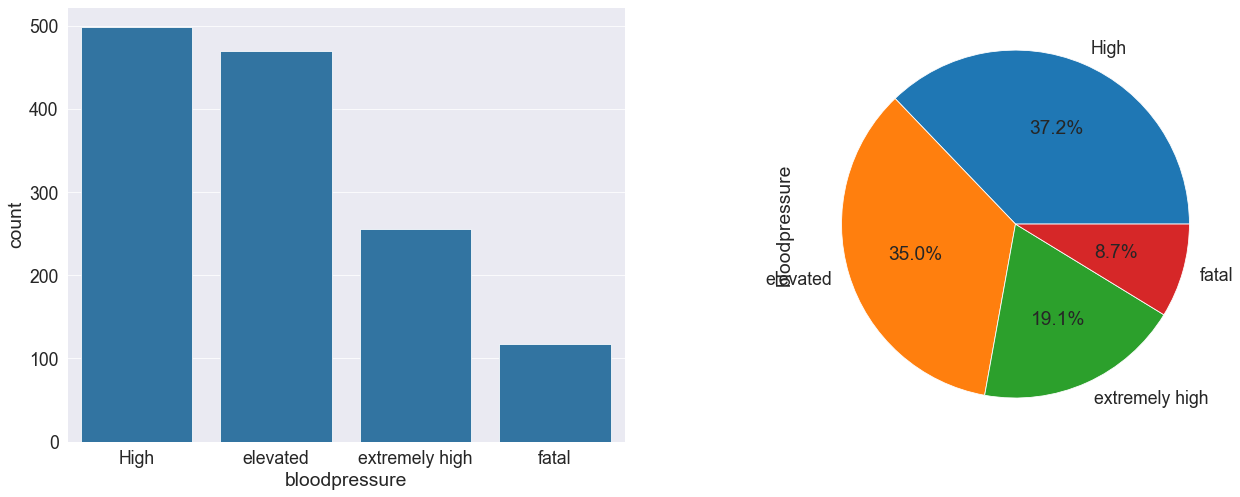

In [46]:
fig = plt.figure(figsize=(22,8))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=cat_df['bloodpressure'],ax=ax1)
cat_df['bloodpressure'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2);


>  **Blood Pressure Distribution**

> - Highly positively skewed.
> - Approximately 35% of patients exhibit elevated BP, while 4.3% are in a critical state (fatal).


### Outliers Detection

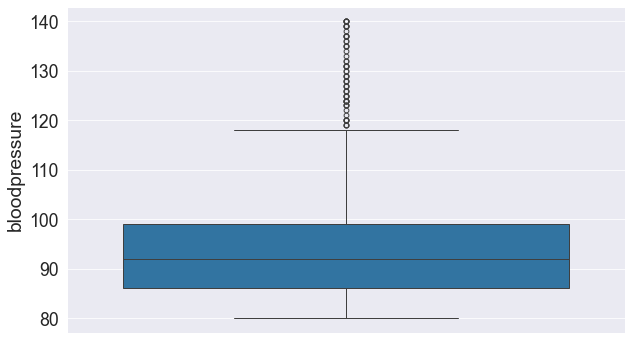

In [47]:
sns.boxplot(df['bloodpressure']);

In [48]:
df.shape

(1340, 9)

### Removing Outliers 

In [49]:
iqr = df['bloodpressure'].quantile(0.75) - df['bloodpressure'].quantile(0.25)
upper_limit= df['bloodpressure'].quantile(0.75) + iqr *1.5
df[df['bloodpressure']>upper_limit].shape

(62, 9)

In [50]:
tmp_bp = df['bloodpressure']

In [51]:
df[df['bloodpressure']>upper_limit].shape[0]/df.shape[0]*100

4.626865671641791

> #### - There are 62 Outliers in BloodPressure Column Which Is 4% of the data 

In [52]:
df['bloodpressure']= np.where(df['bloodpressure'] >upper_limit,upper_limit,df['bloodpressure'])

### After Removal of Outliers

In [53]:
df[df['bloodpressure']>upper_limit].shape[0]/df.shape[0]*100

0.0

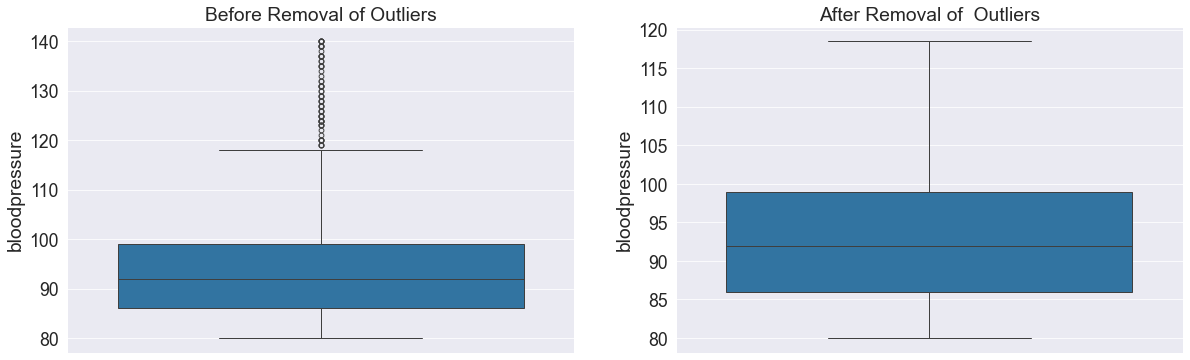

In [54]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
ax1.set_title('Before Removal of Outliers')
sns.boxplot(tmp_bp,ax=ax1);
ax2.set_title('After Removal of  Outliers');
sns.boxplot(df['bloodpressure'],ax=ax2);

> **claim**

> - **Missing Values**     0 
> - **Shape** Positive Skewed
> - **Outliers** 4.6 % Outliers 

In [55]:
df['claim'].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

In [56]:
df['claim'].skew()

1.5167468509489237

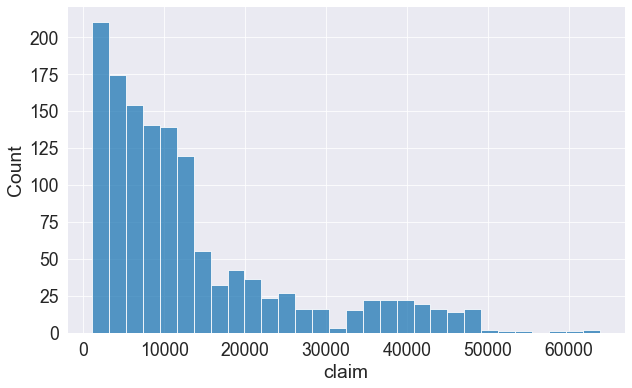

In [57]:
sns.histplot(df['claim']);

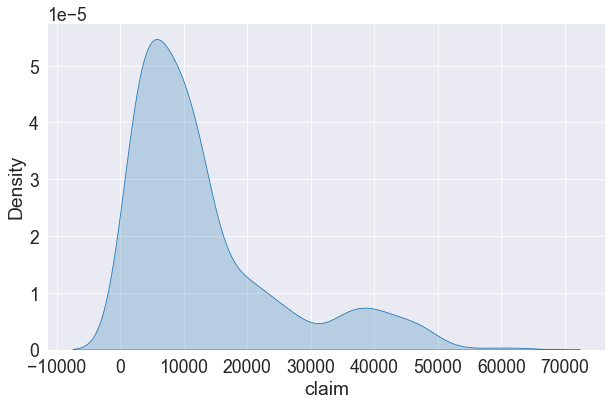

In [58]:
sns.kdeplot(df['claim'],fill=True);

> **Observation**
> - Claim is Highly Positive Skewed

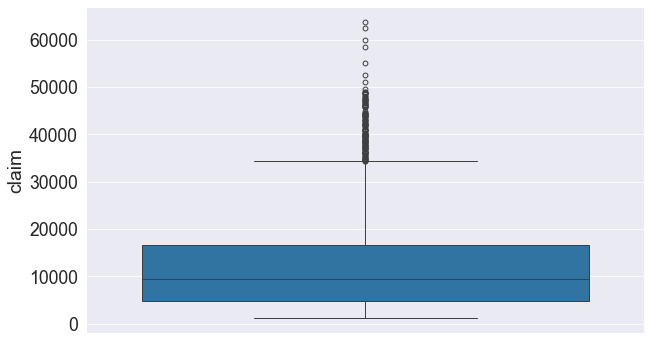

In [59]:
sns.boxplot(df['claim']);

> **claim**

> - Outliers are 10% of the data.
> - highly positively skewed nature.

### Removing Outliers 

In [60]:
iqr = df['claim'].quantile(0.75) - df['claim'].quantile(0.25)
upper_limit= df['claim'].quantile(0.75) + iqr *1.5
df[df['claim']>upper_limit].shape[0]

141

In [61]:
(df[df['claim']>upper_limit].shape[0]/df.shape[0])*100

10.522388059701493

> - There are 141 Outliers in Claim  Which Is 10% of the data 

In [62]:
tmp_claim = df['claim']

In [63]:
df['claim']= np.where(df['claim'] >upper_limit,upper_limit,df['claim'])

### After Removing Outliers 

In [64]:
df[df['claim']>upper_limit].shape[0]

0

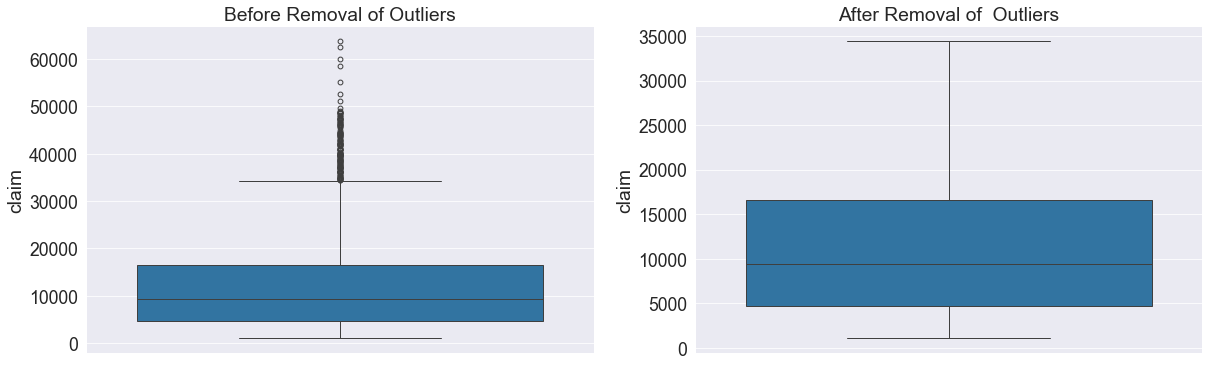

In [65]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
ax1.set_title('Before Removal of Outliers')
sns.boxplot(tmp_claim,ax=ax1);
ax2.set_title('After Removal of  Outliers');
sns.boxplot(df['claim'],ax=ax2);

### Catagorical Columns
- Gender
- diabetic
- Region
- smoker

In [66]:
df['gender'].value_counts()

male      678
female    662
Name: gender, dtype: int64

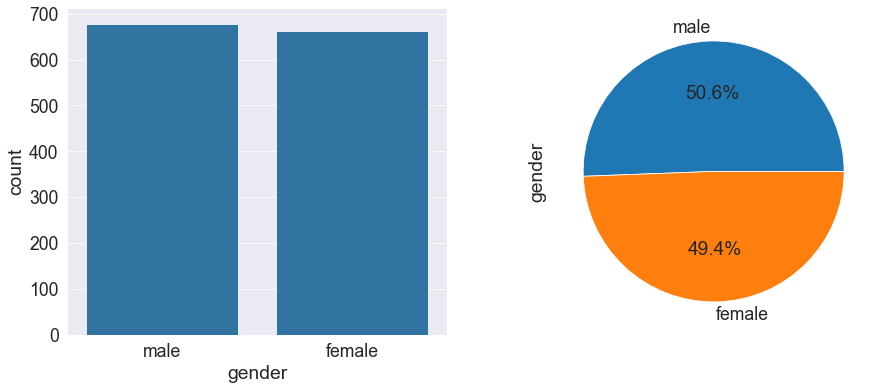

In [67]:
fig = plt.figure(figsize=(15,6))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=df['gender'],ax=ax1)
df['gender'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2);

In [68]:
df['diabetic'].value_counts()

No     698
Yes    642
Name: diabetic, dtype: int64

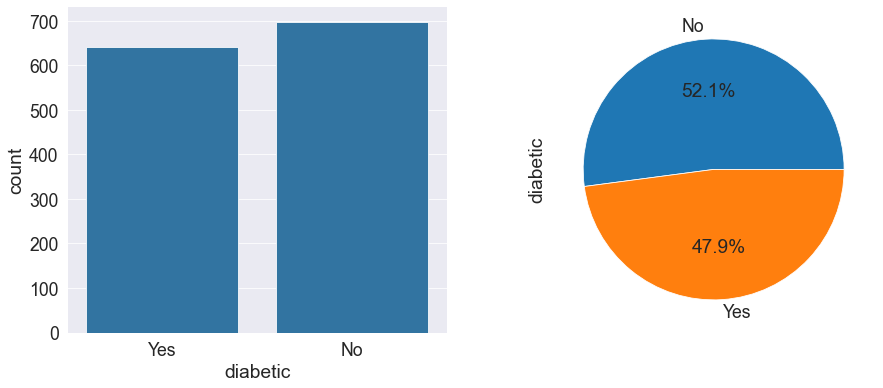

In [69]:
fig = plt.figure(figsize=(15,6))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=df['diabetic'],ax=ax1)
df['diabetic'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2);

### 1. **Observations:**
  - A significant proportion, accounting for 47.9% of individuals, report having diabetes.


In [70]:
df['children'].value_counts()

0    576
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

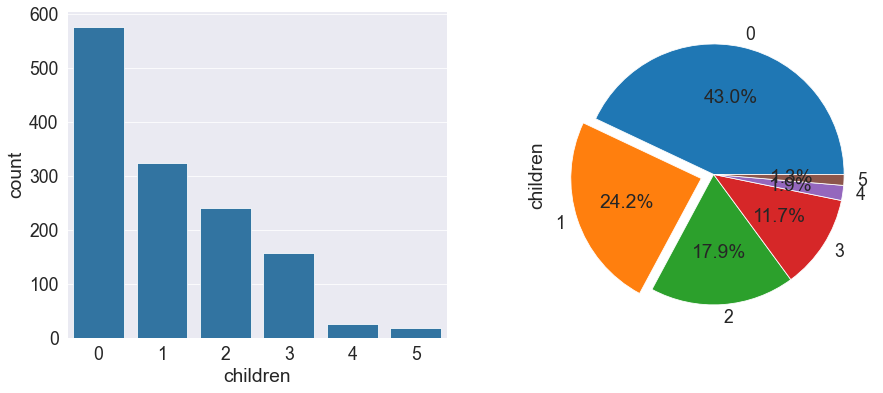

In [71]:
fig = plt.figure(figsize=(15,6))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=df['children'],ax=ax1)
df['children'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2,explode=[0,0.1,0,0,0,0]);

In [72]:
df['smoker'].value_counts()

No     1066
Yes     274
Name: smoker, dtype: int64

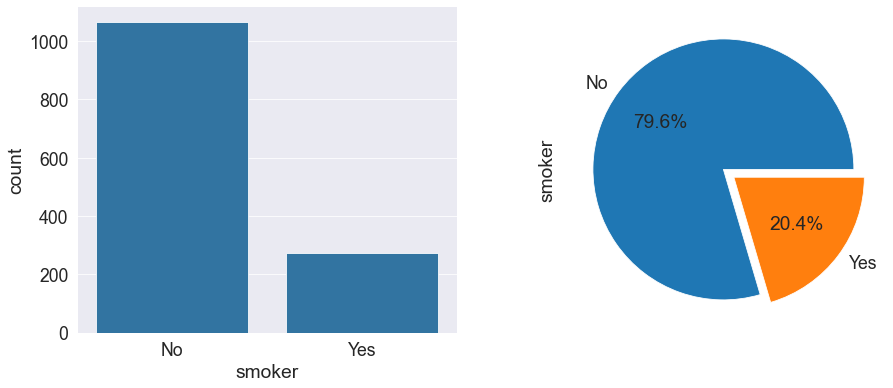

In [73]:
fig = plt.figure(figsize=(15,6))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=df['smoker'],ax=ax1)
df['smoker'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2,explode=[0,0.1]);

### Observations

-  The dataset reveals that approximately 20.6% of individuals identify as smokers.


In [74]:
df['region'].value_counts()

southeast    443
northwest    349
southwest    314
northeast    231
Name: region, dtype: int64

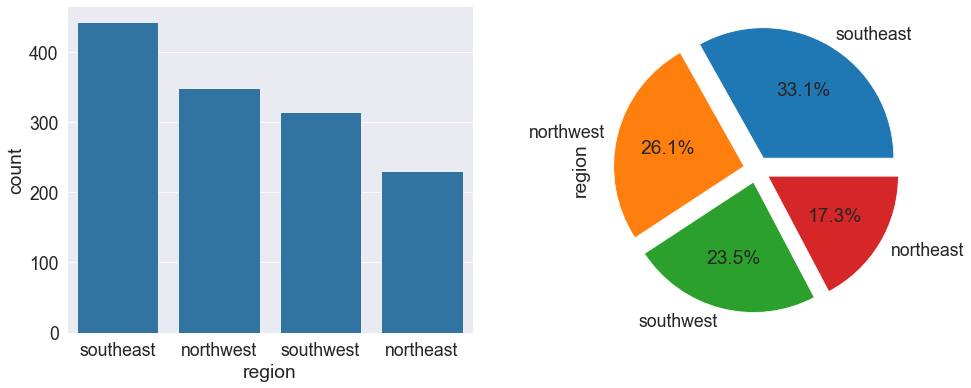

In [75]:
fig = plt.figure(figsize=(16,6))
(ax1,ax2) = fig.subplots(1,2)
sns.countplot(x=df['region'],ax=ax1)
df['region'].value_counts().plot(kind='pie',autopct='%0.1f%%',ax=ax2,explode=[0.1]*4);

In [76]:
pd.crosstab(df['gender'],df['diabetic'])

diabetic,No,Yes
gender,,
female,339,323
male,359,319


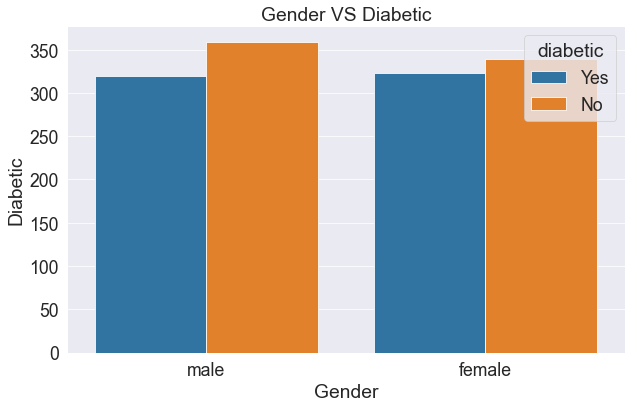

In [77]:
sns.countplot(x=df['gender'],hue=df['diabetic'])
plt.xlabel('Gender')
plt.ylabel('Diabetic')
plt.title('Gender VS Diabetic')
plt.show();

In [78]:
pd.crosstab(df['gender'],df['smoker'])

smoker,No,Yes
gender,,
female,547,115
male,519,159


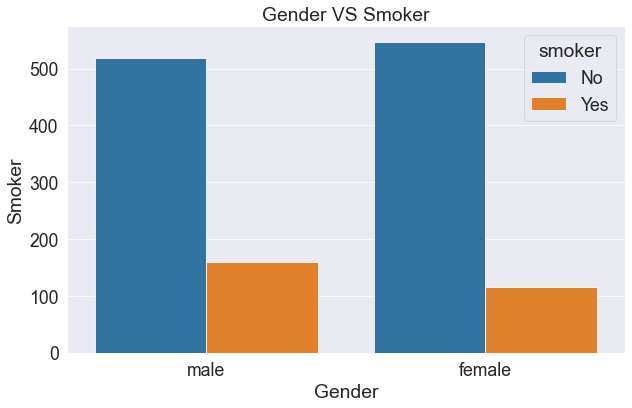

In [79]:
sns.countplot(x=df['gender'],hue=df['smoker'])
plt.xlabel('Gender')
plt.ylabel('Smoker')
plt.title('Gender VS Smoker')
plt.show();

In [80]:
pd.crosstab(df['gender'],df['region'])

region,northeast,northwest,southeast,southwest
gender,,,,
female,112,164,224,162
male,119,185,219,152


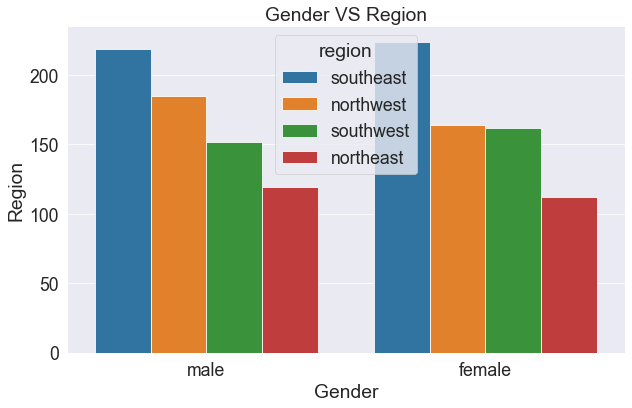

In [81]:
sns.countplot(x=df['gender'],hue=df['region'])
plt.xlabel('Gender')
plt.ylabel('Region')
plt.title('Gender VS Region')
plt.show();

In [82]:
pd.crosstab(df['gender'],cat_df['bloodpressure'])

bloodpressure,High,elevated,extremely high,fatal
gender,,,,
female,249,235,129,49
male,249,234,127,68


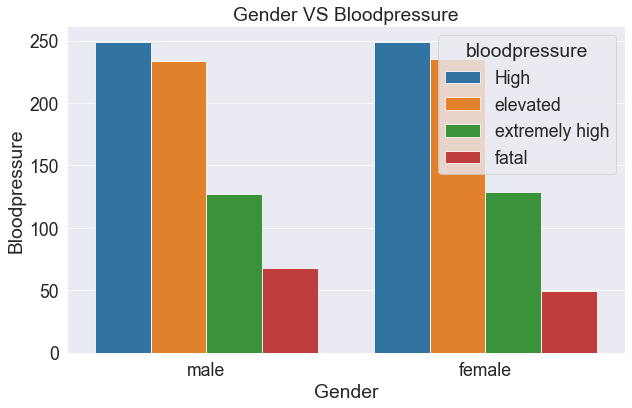

In [83]:
sns.countplot(x=df['gender'],hue=cat_df['bloodpressure'])
plt.xlabel('Gender')
plt.ylabel('Bloodpressure')
plt.title('Gender VS Bloodpressure')
plt.show();

In [84]:
pd.crosstab(df['gender'],cat_df['bmi'])

bmi,Healthy,Obese,Overweight,Underweight,Very Obese
gender,,,,,
female,114,293,191,12,52
male,106,322,186,8,56


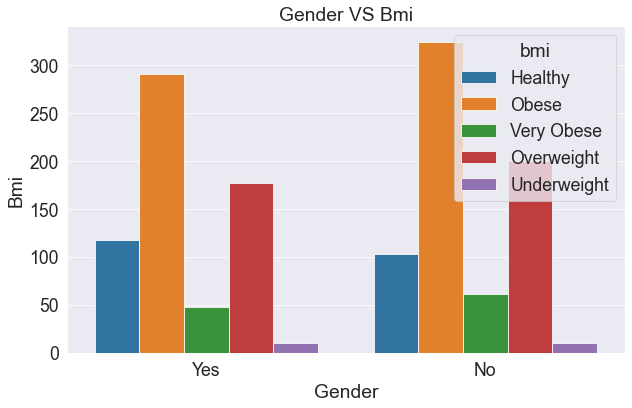

In [85]:
sns.countplot(x=df['diabetic'],hue=cat_df['bmi'])
plt.xlabel('Gender')
plt.ylabel('Bmi')
plt.title('Gender VS Bmi')
plt.show()

In [86]:
pd.crosstab(df['diabetic'],df['smoker'])

smoker,No,Yes
diabetic,,
No,560,138
Yes,506,136


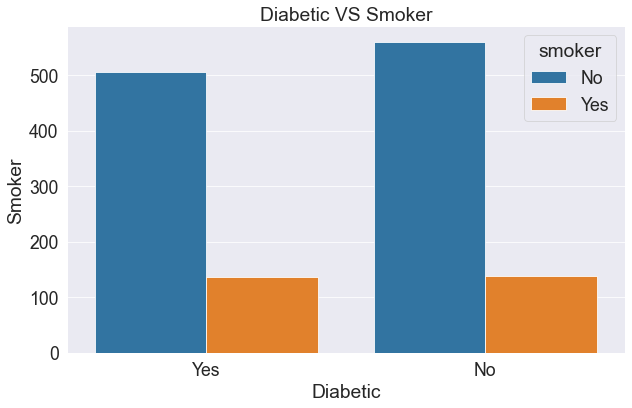

In [87]:
sns.countplot(x=df['diabetic'],hue=df['smoker'])
plt.xlabel('Diabetic')
plt.ylabel('Smoker')
plt.title('Diabetic VS Smoker')
plt.show();

In [88]:
pd.crosstab(df['diabetic'],df['children'])

children,0,1,2,3,4,5
diabetic,,,,,,
No,292,179,120,83,13,11
Yes,284,145,120,74,12,7


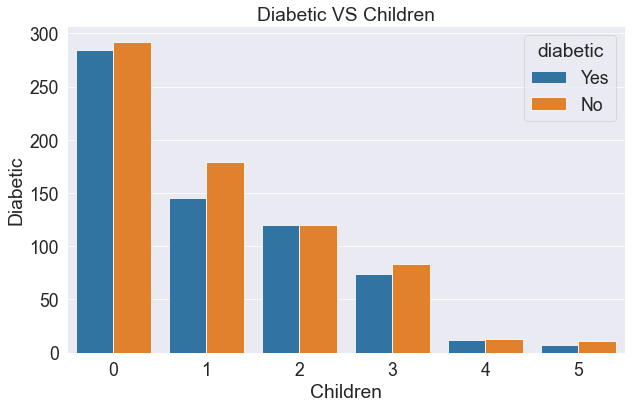

In [89]:
sns.countplot(hue=df['diabetic'],x=df['children'])
plt.xlabel('Children')
plt.ylabel('Diabetic')
plt.title('Diabetic VS Children')
plt.show()

In [90]:
pd.crosstab(df['diabetic'],df['region'])

region,northeast,northwest,southeast,southwest
diabetic,,,,
No,110,192,225,170
Yes,121,157,218,144


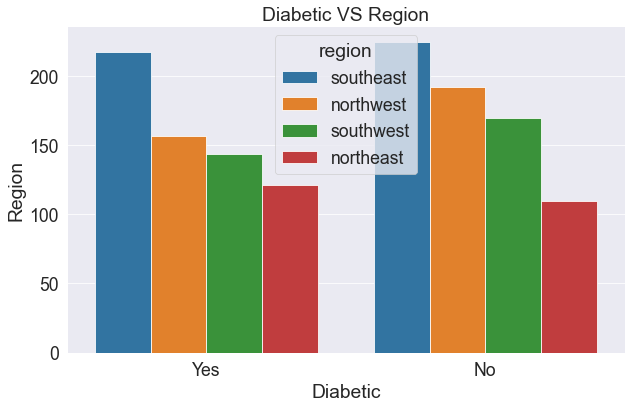

In [91]:
sns.countplot(x=df['diabetic'],hue=df['region'])
plt.xlabel('Diabetic')
plt.ylabel('Region')
plt.title('Diabetic VS Region')
plt.show()

In [92]:
pd.crosstab(df['diabetic'],cat_df['bloodpressure'])

bloodpressure,High,elevated,extremely high,fatal
diabetic,,,,
No,282,231,125,60
Yes,216,238,131,57


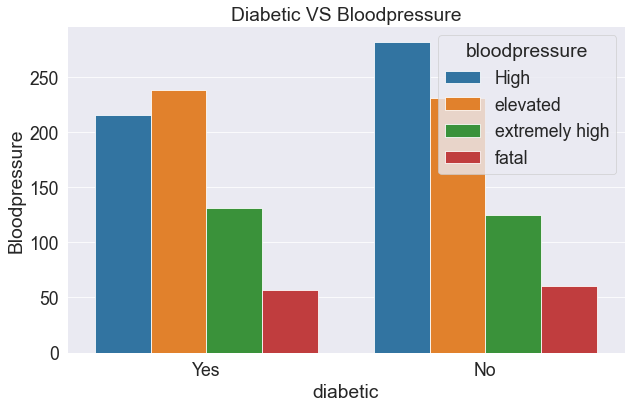

In [93]:
sns.countplot(x=df['diabetic'],hue=cat_df['bloodpressure'])
plt.xlabel('diabetic')
plt.ylabel('Bloodpressure')
plt.title('Diabetic VS Bloodpressure')
plt.show()

In [94]:
pd.crosstab(df['diabetic'],cat_df['bmi'])

bmi,Healthy,Obese,Overweight,Underweight,Very Obese
diabetic,,,,,
No,103,324,200,10,61
Yes,117,291,177,10,47


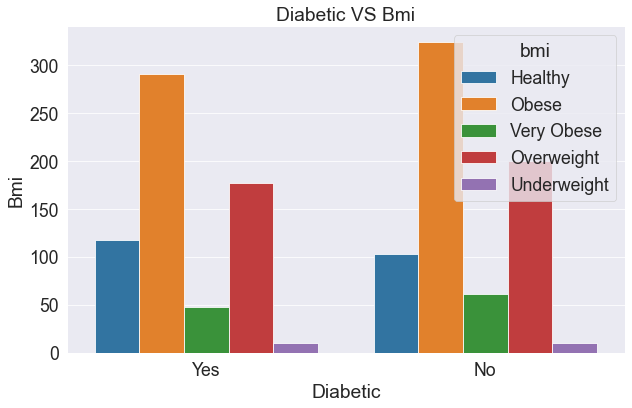

In [95]:
sns.countplot(x=df['diabetic'],hue=cat_df['bmi'])
plt.xlabel('Diabetic')
plt.ylabel('Bmi')
plt.title('Diabetic VS Bmi')
plt.show()

In [96]:
pd.crosstab(df['smoker'],df['children'])

children,0,1,2,3,4,5
smoker,,,,,,
No,461,263,185,118,22,17
Yes,115,61,55,39,3,1


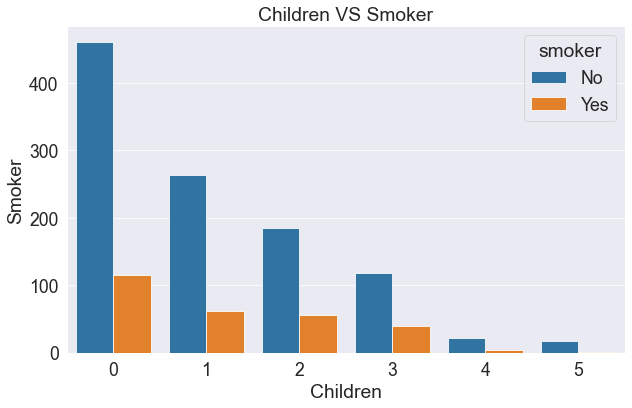

In [97]:
sns.countplot(hue=df['smoker'],x=df['children'])
plt.xlabel('Children')
plt.ylabel('Smoker')
plt.title('Children VS Smoker')
plt.show();

In [98]:
pd.crosstab(df['region'],df['smoker'])

smoker,No,Yes
region,,
northeast,164,67
northwest,291,58
southeast,352,91
southwest,256,58


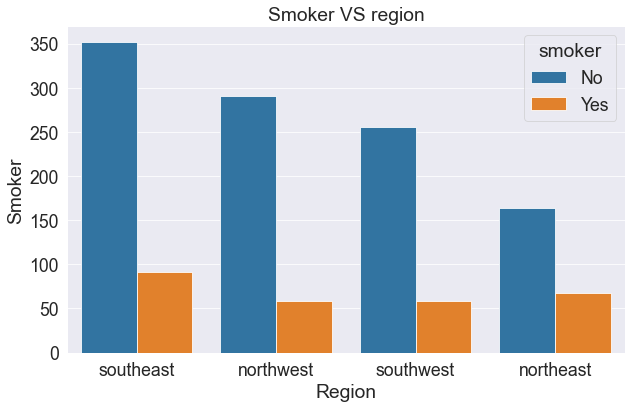

In [99]:
sns.countplot(hue=df['smoker'],x=df['region'])
plt.xlabel('Region')
plt.ylabel('Smoker')
plt.title('Smoker VS region')
plt.show()

In [100]:
pd.crosstab(df['smoker'],cat_df['bloodpressure'])

bloodpressure,High,elevated,extremely high,fatal
smoker,,,,
No,437,411,159,59
Yes,61,58,97,58


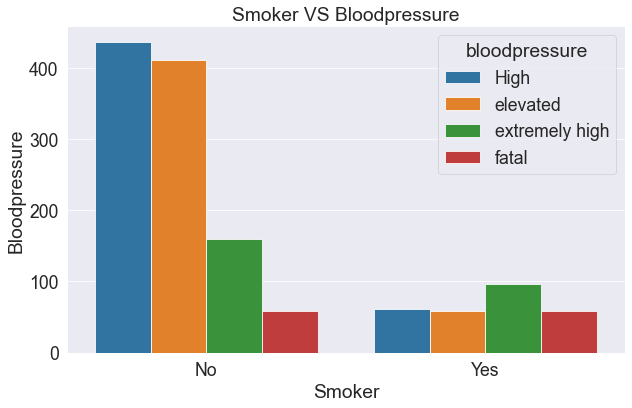

In [101]:
sns.countplot(x=df['smoker'],hue=cat_df['bloodpressure'])
plt.xlabel('Smoker')
plt.ylabel('Bloodpressure')
plt.title('Smoker VS Bloodpressure')
plt.show()

In [102]:
pd.crosstab(df['smoker'],cat_df['bmi'])

bmi,Healthy,Obese,Overweight,Underweight,Very Obese
smoker,,,,,
No,171,491,305,15,84
Yes,49,124,72,5,24


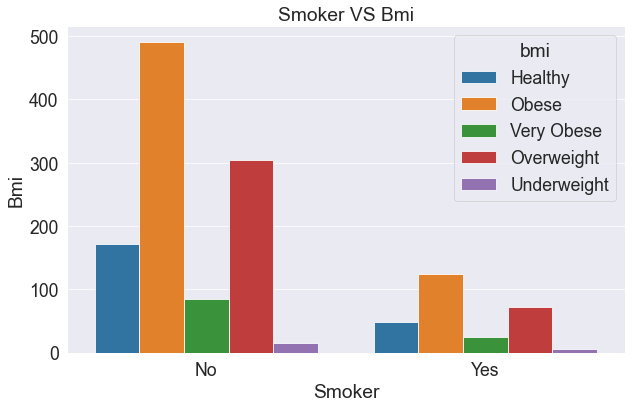

In [103]:
sns.countplot(x=df['smoker'],hue=cat_df['bmi'])
plt.xlabel('Smoker')
plt.ylabel('Bmi')
plt.title('Smoker VS Bmi')
plt.show()

### Catagorical and Numerical Columns

- gender with bmi
- gender with bloodpressure
- gender with claim
- diabetic with bmi
- diabetic with bloodpressure
- diabetic with claim
- smoker with bmi
- smoker with bloodpressure
- smoker with claim
- region with bmi
- region with bloodpressure
- region with claim
- cat_bmi with claim
- cat_bloodpressure with claim

In [104]:
sns.set_context('paper', font_scale = 2.3)

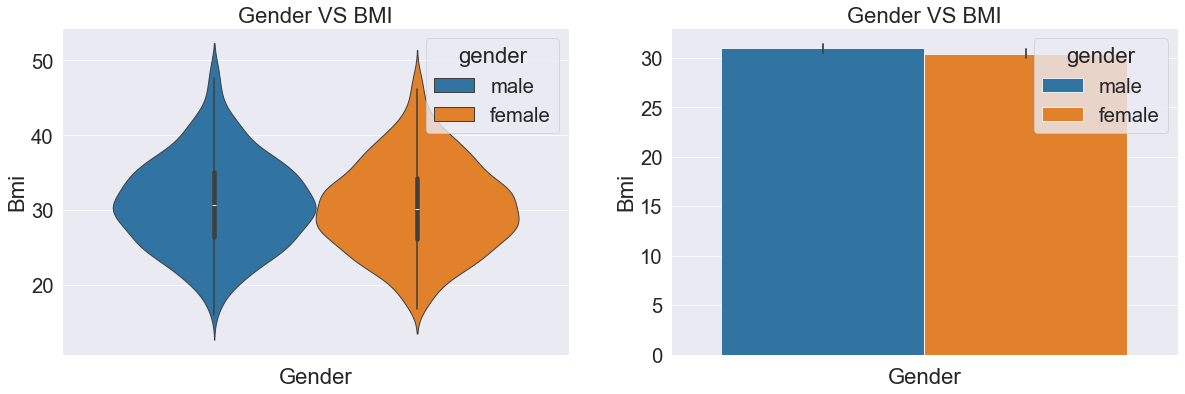

In [105]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['gender'],y=df['bmi'],ax=ax1)
ax1.set_xlabel('Gender')
ax1.set_ylabel('Bmi')
ax1.set_title('Gender VS BMI')

sns.barplot(hue=df['gender'],y=df['bmi'],ax=ax2)
ax2.set_xlabel('Gender')
ax2.set_ylabel('Bmi')
ax2.set_title('Gender VS BMI');

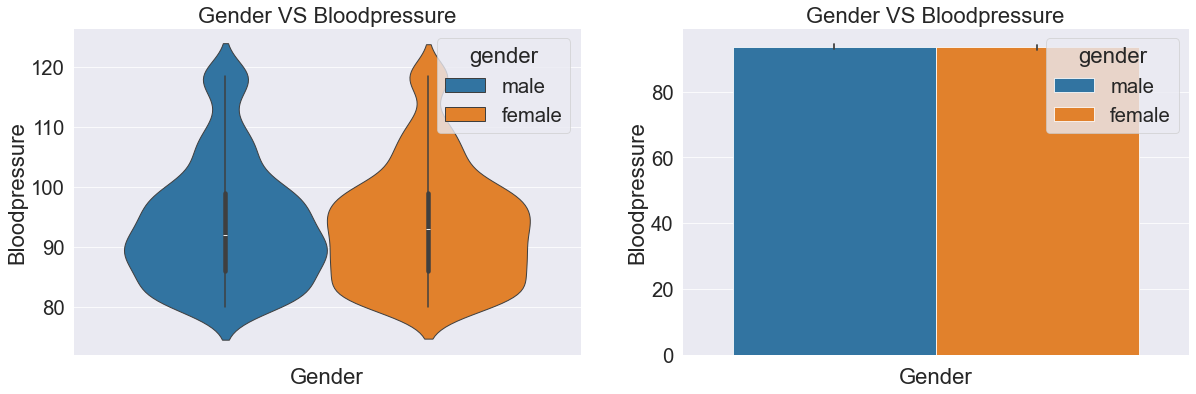

In [106]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['gender'],y=df['bloodpressure'],ax=ax1)
ax1.set_xlabel('Gender')
ax1.set_ylabel('Bloodpressure')
ax1.set_title('Gender VS Bloodpressure')

sns.barplot(hue=df['gender'],y=df['bloodpressure'],ax=ax2)
ax2.set_xlabel('Gender')
ax2.set_ylabel('Bloodpressure')
ax2.set_title('Gender VS Bloodpressure');

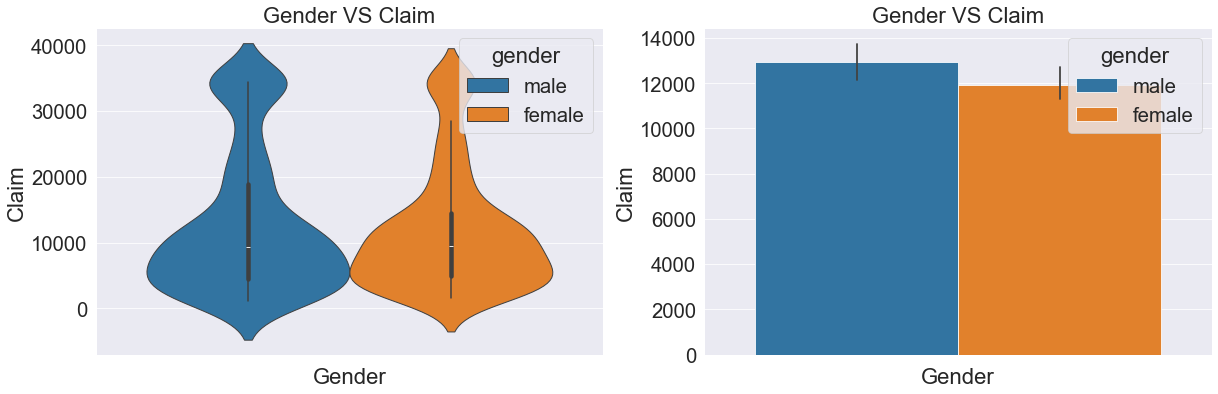

In [107]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['gender'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Gender')
ax1.set_ylabel('Claim')
ax1.set_title('Gender VS Claim')

sns.barplot(hue=df['gender'],y=df['claim'],ax=ax2)
ax2.set_xlabel('Gender')
ax2.set_ylabel('Claim')
ax2.set_title('Gender VS Claim');

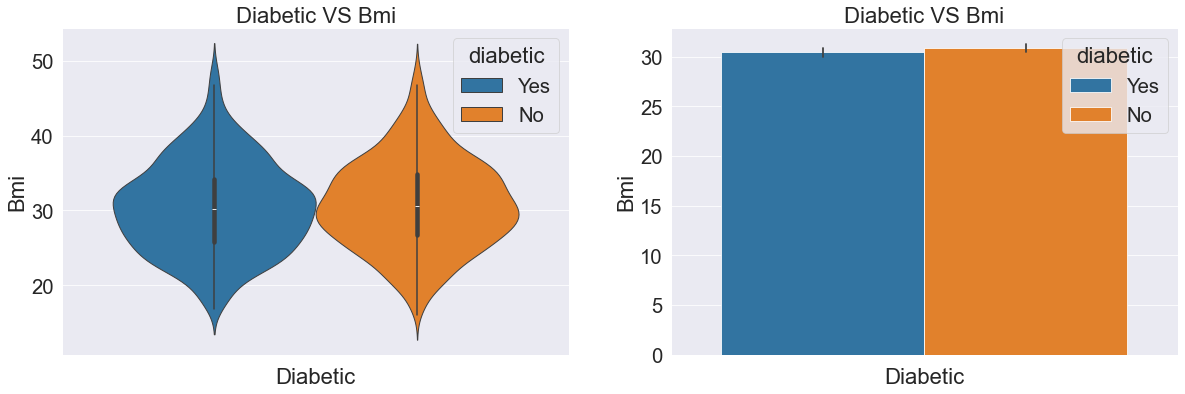

In [108]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['diabetic'],y=df['bmi'],ax=ax1)
ax1.set_xlabel('Diabetic')
ax1.set_ylabel('Bmi')
ax1.set_title('Diabetic VS Bmi')

sns.barplot(hue=df['diabetic'],y=df['bmi'],ax=ax2)
ax2.set_xlabel('Diabetic')
ax2.set_ylabel('Bmi')
ax2.set_title('Diabetic VS Bmi');

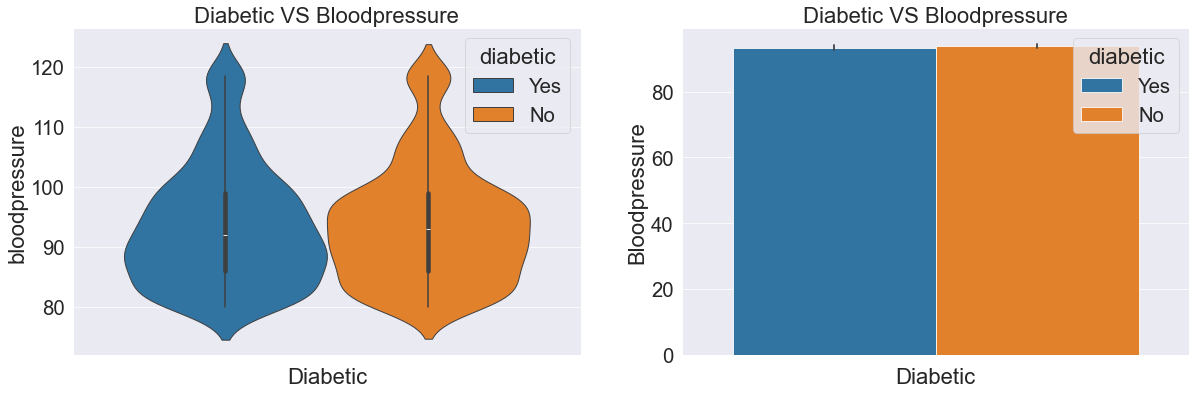

In [109]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['diabetic'],y=df['bloodpressure'],ax=ax1)
ax1.set_xlabel('Diabetic')
ax1.set_ylabel('bloodpressure')
ax1.set_title('Diabetic VS Bloodpressure')
sns.barplot(hue=df['diabetic'],y=df['bloodpressure'],ax=ax2)
ax2.set_xlabel('Diabetic')
ax2.set_ylabel('Bloodpressure')
ax2.set_title('Diabetic VS Bloodpressure');

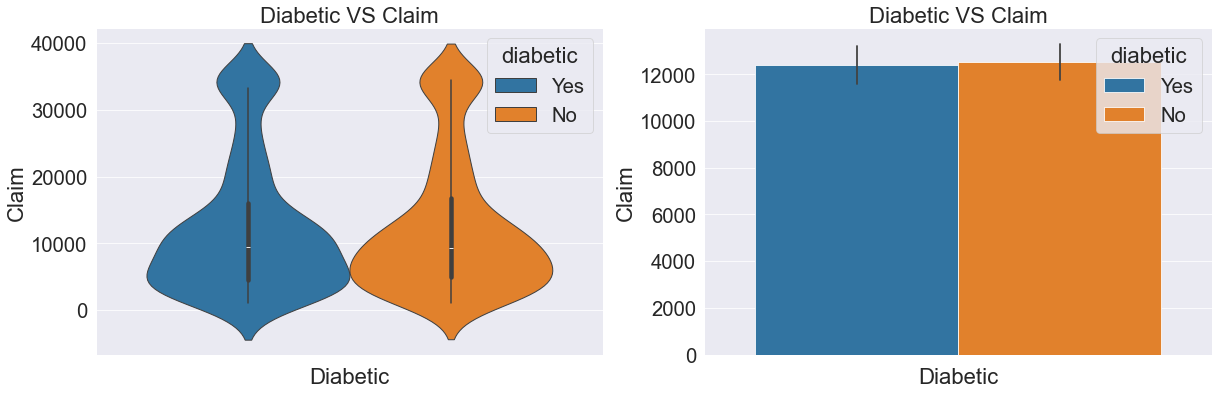

In [110]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['diabetic'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Diabetic')
ax1.set_ylabel('Claim')
ax1.set_title('Diabetic VS Claim')
sns.barplot(hue=df['diabetic'],y=df['claim'],ax=ax2)
ax2.set_xlabel('Diabetic')
ax2.set_ylabel('Claim')
ax2.set_title('Diabetic VS Claim');

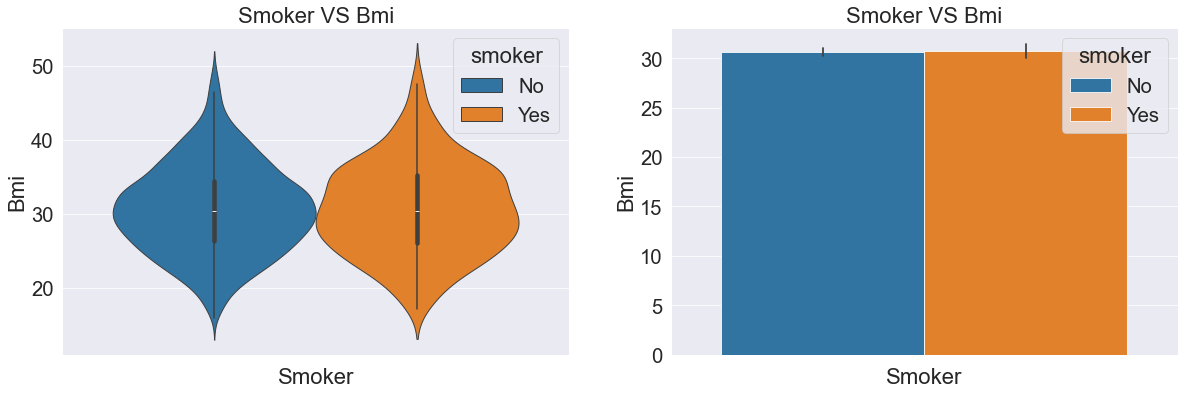

In [111]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['smoker'],y=df['bmi'],ax=ax1)
ax1.set_xlabel('Smoker')
ax1.set_ylabel('Bmi')
ax1.set_title('Smoker VS Bmi')
sns.barplot(hue=df['smoker'],y=df['bmi'],ax=ax2)
ax2.set_xlabel('Smoker')
ax2.set_ylabel('Bmi')
ax2.set_title('Smoker VS Bmi');

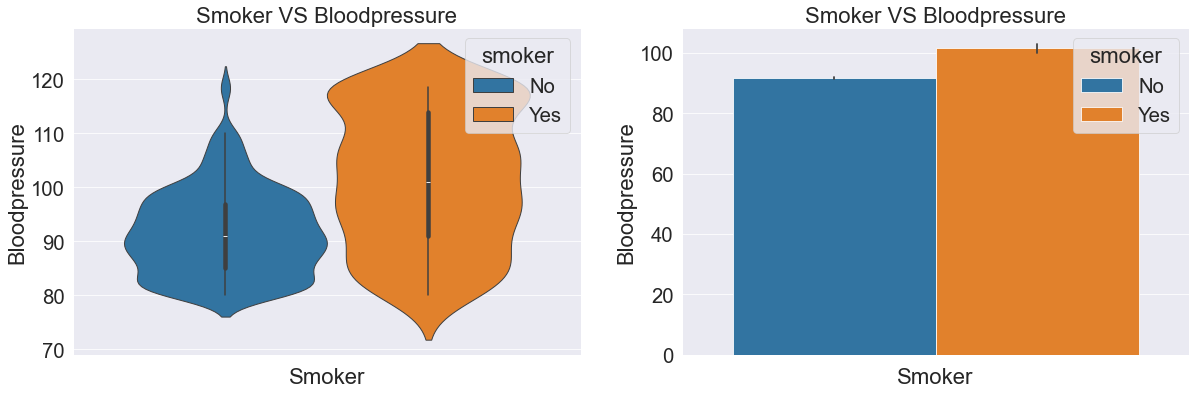

In [112]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['smoker'],y=df['bloodpressure'],ax=ax1)
ax1.set_xlabel('Smoker')
ax1.set_ylabel('Bloodpressure')
ax1.set_title('Smoker VS Bloodpressure')
sns.barplot(hue=df['smoker'],y=df['bloodpressure'],ax=ax2)
ax2.set_xlabel('Smoker')
ax2.set_ylabel('Bloodpressure')
ax2.set_title('Smoker VS Bloodpressure');

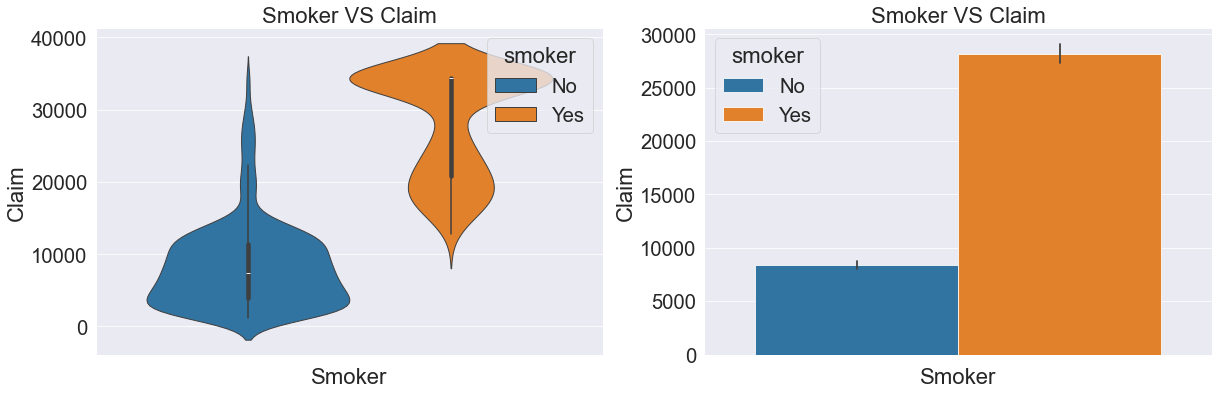

In [113]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['smoker'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Smoker')
ax1.set_ylabel('Claim')
ax1.set_title('Smoker VS Claim')
sns.barplot(hue=df['smoker'],y=df['claim'],ax=ax2)
ax2.set_xlabel('Smoker')
ax2.set_ylabel('Claim')
ax2.set_title('Smoker VS Claim');

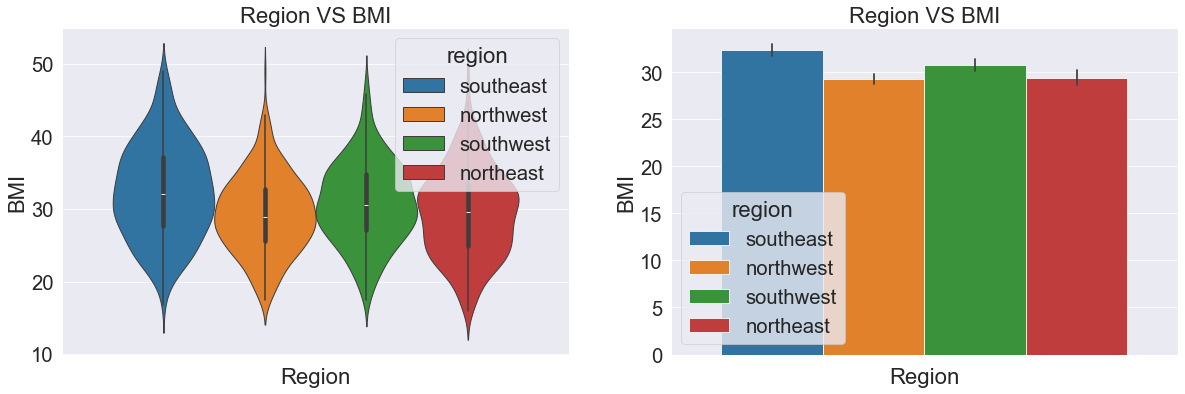

In [114]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['region'],y=df['bmi'],ax=ax1)
ax1.set_xlabel('Region')
ax1.set_ylabel('BMI')
ax1.set_title('Region VS BMI')
sns.barplot(hue=df['region'],y=df['bmi'],ax=ax2)
ax2.set_xlabel('Region')
ax2.set_ylabel('BMI')
ax2.set_title('Region VS BMI');

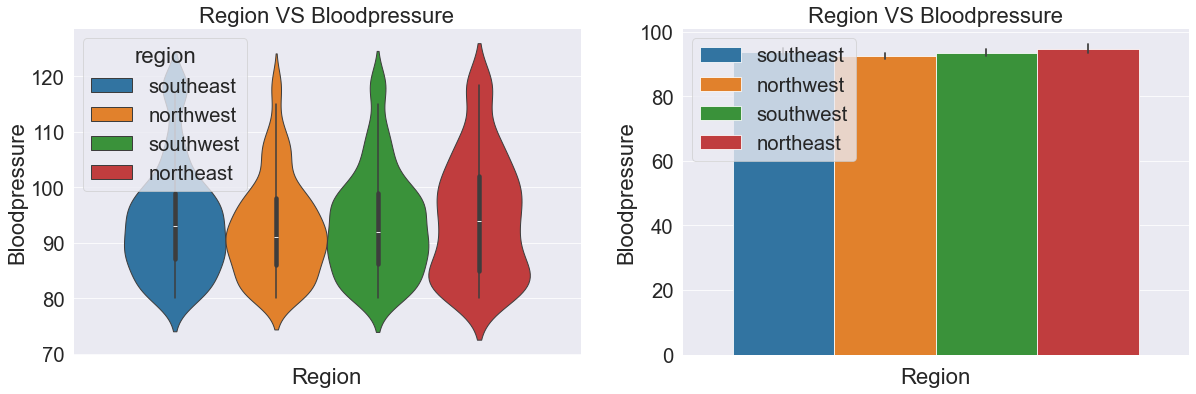

In [115]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['region'],y=df['bloodpressure'],ax=ax1)
ax1.set_xlabel('Region')
ax1.set_ylabel('Bloodpressure')
ax1.set_title('Region VS Bloodpressure')
sns.barplot(hue=df['region'],y=df['bloodpressure'],ax=ax2)
ax2.set_xlabel('Region')
ax2.set_ylabel('Bloodpressure')
ax2.set_title('Region VS Bloodpressure');
plt.legend(loc='upper left');

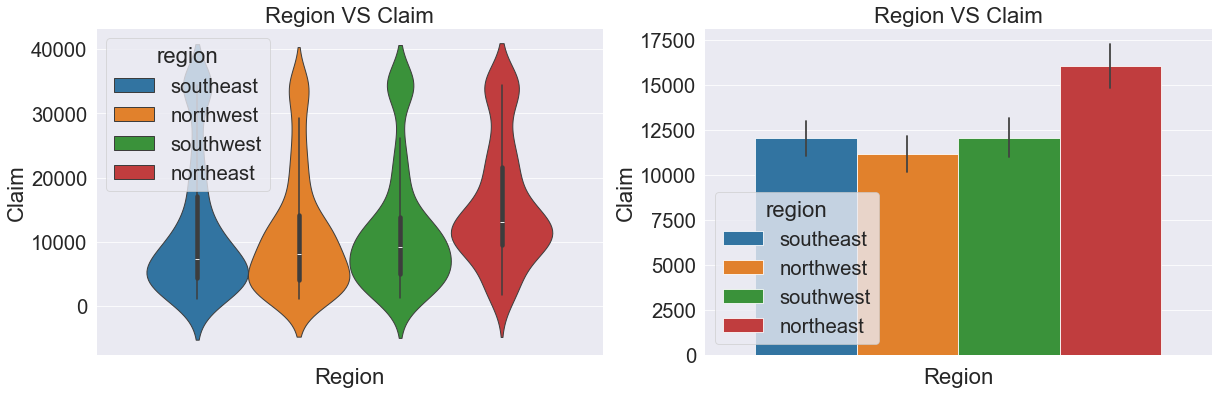

In [116]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=df['region'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Region')
ax1.set_ylabel('Claim')
ax1.set_title('Region VS Claim')
sns.barplot(hue=df['region'],y=df['claim'],ax=ax2)
ax2.set_xlabel('Region')
ax2.set_ylabel('Claim')
ax2.set_title('Region VS Claim');

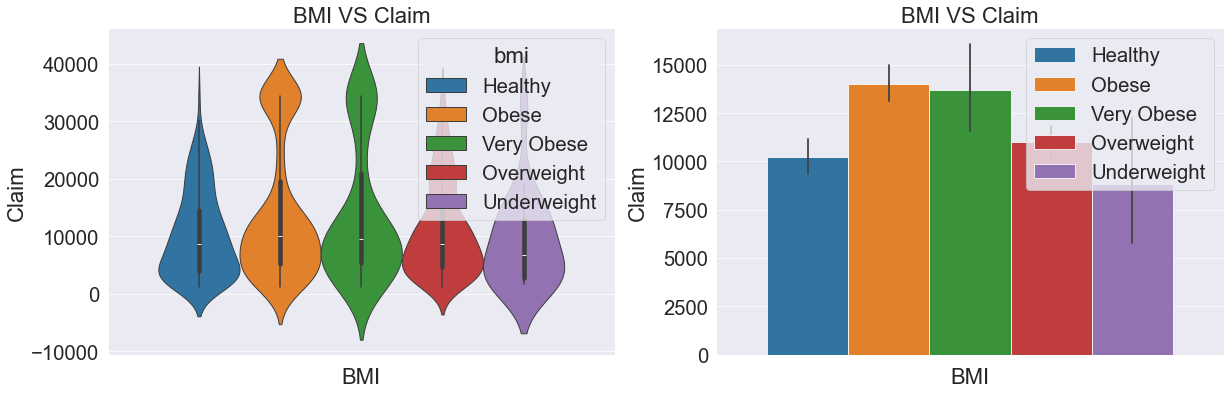

In [117]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=cat_df['bmi'],y=df['claim'],ax=ax1)
ax1.set_xlabel('BMI')
ax1.set_ylabel('Claim')
ax1.set_title('BMI VS Claim')
sns.barplot(hue=cat_df['bmi'],y=df['claim'],ax=ax2)
plt.legend(loc='upper right')
ax2.set_xlabel('BMI')
ax2.set_ylabel('Claim')
ax2.set_title('BMI VS Claim');

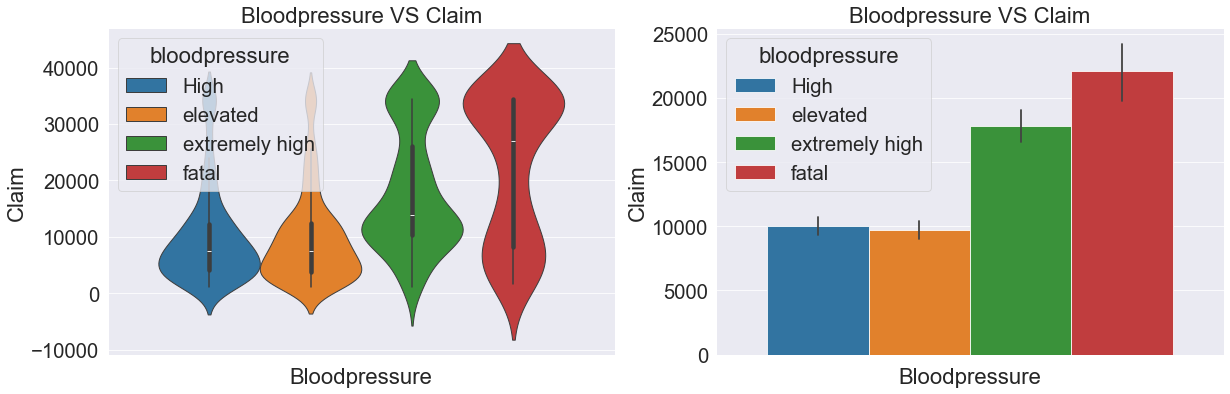

In [118]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(hue=cat_df['bloodpressure'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Bloodpressure')
ax1.set_ylabel('Claim')
ax1.set_title('Bloodpressure VS Claim')

sns.barplot(hue=cat_df['bloodpressure'],y=df['claim'],ax=ax2)
ax2.set_xlabel('Bloodpressure')
ax2.set_ylabel('Claim')
ax2.set_title('Bloodpressure VS Claim');

# Num to Num
- Age with bmi
- Age with bloodpressure
- Age with claim
- bmi with claim
- bmi with bloodpressure
- bloodpressure with  claim



## Age Vs BloodPressure  Age Vs BMI 

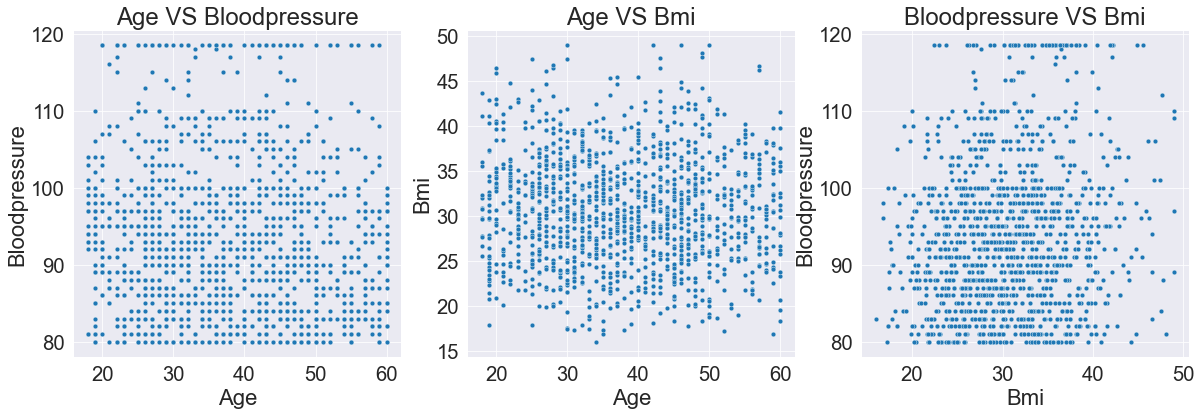

In [119]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2,ax3) = fig.subplots(1,3)
sns.scatterplot(x=df['age'],y=df['bloodpressure'],ax=ax1);
ax1.set_xlabel('Age')
ax1.set_ylabel('Bloodpressure')
ax1.set_title('Age VS Bloodpressure', fontsize=24, loc='center')

sns.scatterplot(x=df['age'],y=df['bmi'],ax=ax2);
ax2.set_xlabel('Age')
ax2.set_ylabel('Bmi')
ax2.set_title('Age VS Bmi', fontsize=24, loc='center')

sns.scatterplot(x=df['bmi'],y=df['bloodpressure']);
ax3.set_xlabel('Bmi')
ax3.set_ylabel('Bloodpressure')
ax3.set_title('Bloodpressure VS Bmi', fontsize=24, loc='center');

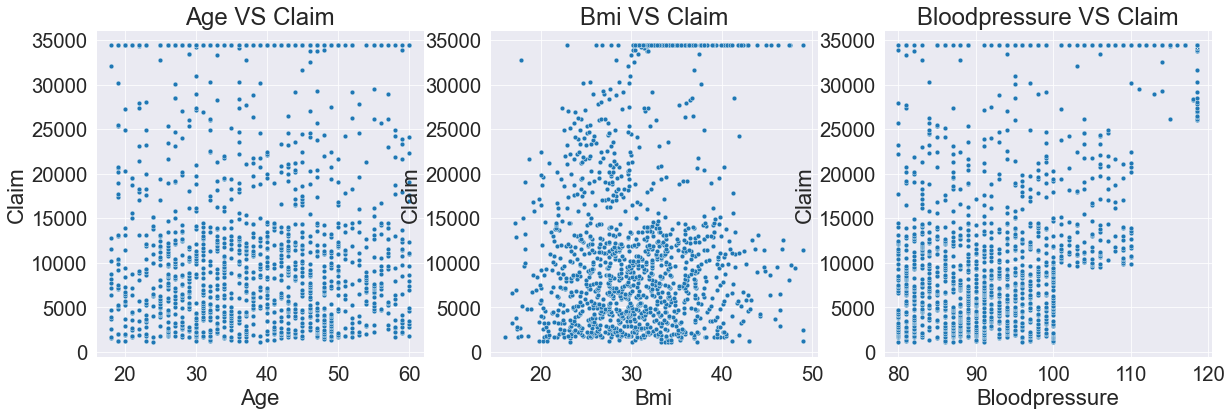

In [120]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2,ax3) = fig.subplots(1,3)
sns.scatterplot(x=df['age'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Age')
ax1.set_ylabel('Claim')
ax1.set_title('Age VS Claim', fontsize=24, loc='center');

sns.scatterplot(x=df['bmi'],y=df['claim'],ax=ax2);
ax2.set_xlabel('Bmi')
ax2.set_ylabel('Claim')
ax2.set_title('Bmi VS Claim', fontsize=24, loc='center');

sns.scatterplot(x=df['bloodpressure'],y=df['claim'],ax=ax3);
ax3.set_xlabel('Bloodpressure')
ax3.set_ylabel('Claim')
ax3.set_title('Bloodpressure VS Claim', fontsize=24, loc='center');



In [121]:
df[num_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.000000,-0.042350,-0.071450,-0.025547,-0.029839
bmi,-0.042350,1.000000,0.141027,0.012655,0.159282
bloodpressure,-0.071450,0.141027,1.000000,-0.029573,0.507597
children,-0.025547,0.012655,-0.029573,1.000000,0.074492
claim,-0.029839,0.159282,0.507597,0.074492,1.000000


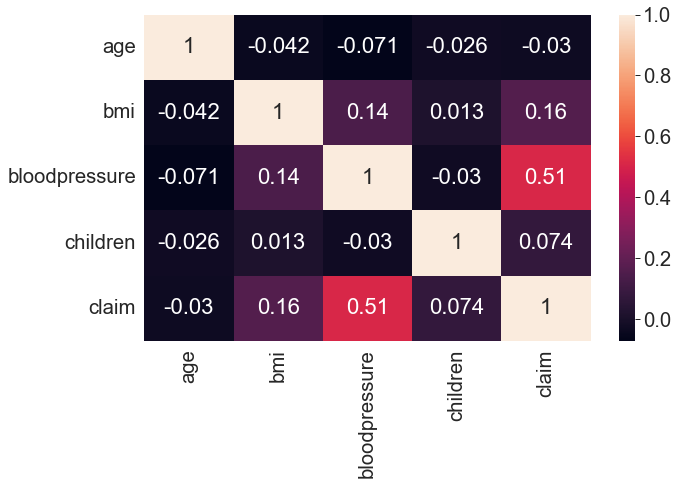

In [122]:
sns.heatmap(df[num_cols].corr(), annot=True);

### Multivariate Data Anaysis

### Cat to Cat
- gender with diabetic with smoker
- gender with children with smoker
- gender with region with smoker
- bmi_cat with diabetic with smoker
- bmi_cat with children with smoker
- bmi_cat with region with smoker
- blood_ptressure_cat with diabetic with smoker
- blood_ptressure_cat with children with smoker
- blood_ptressure_cat with region with smoker




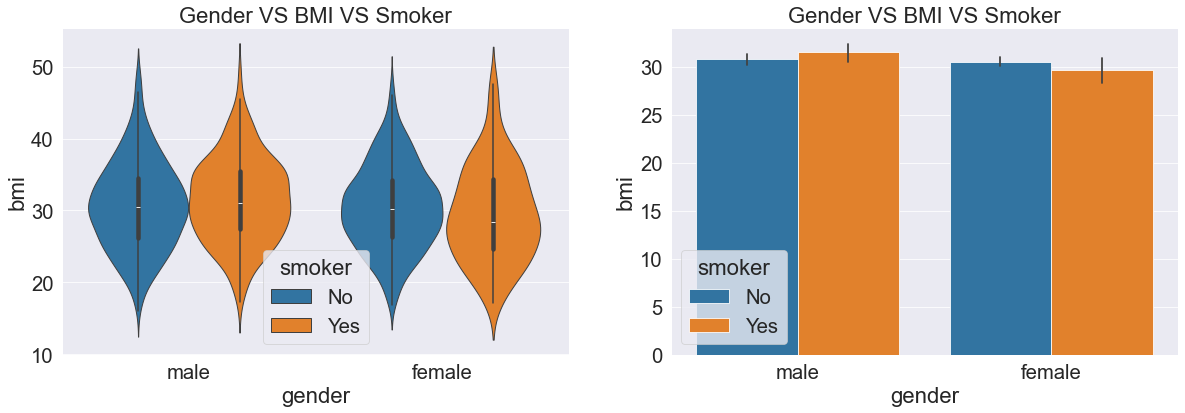

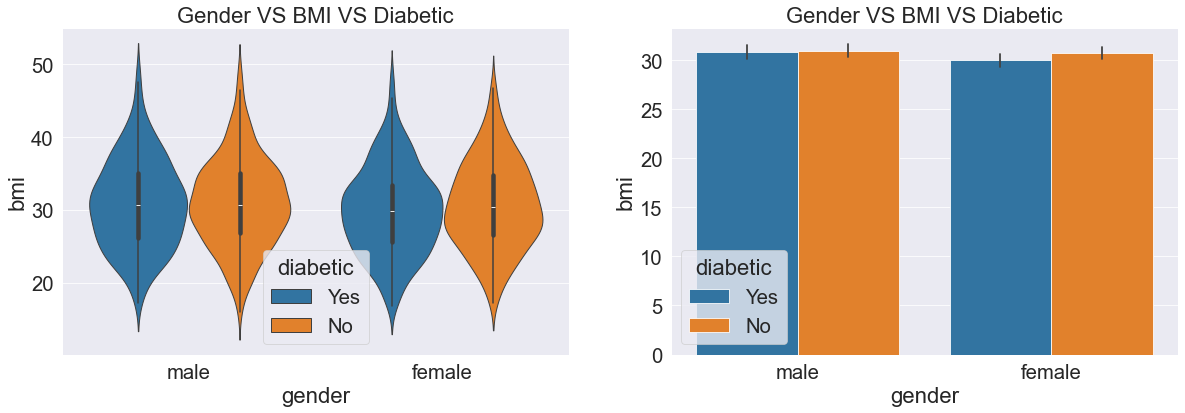

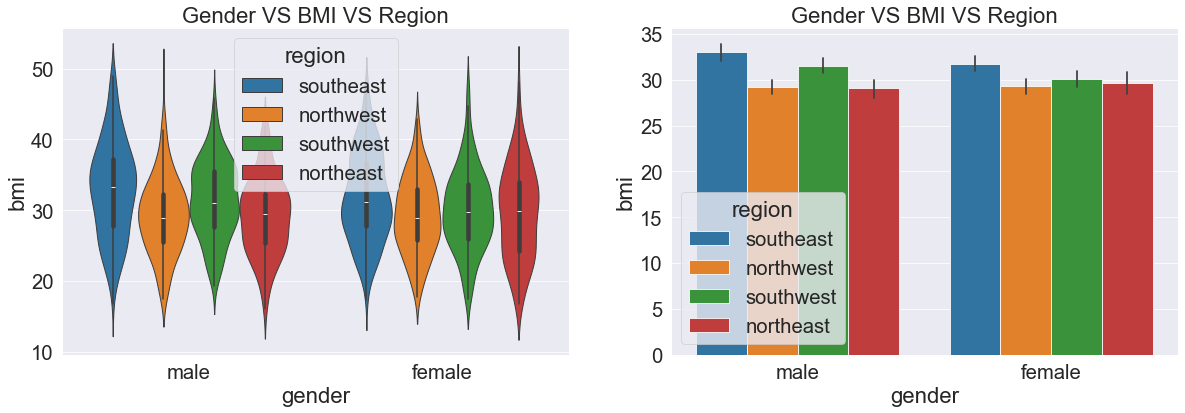

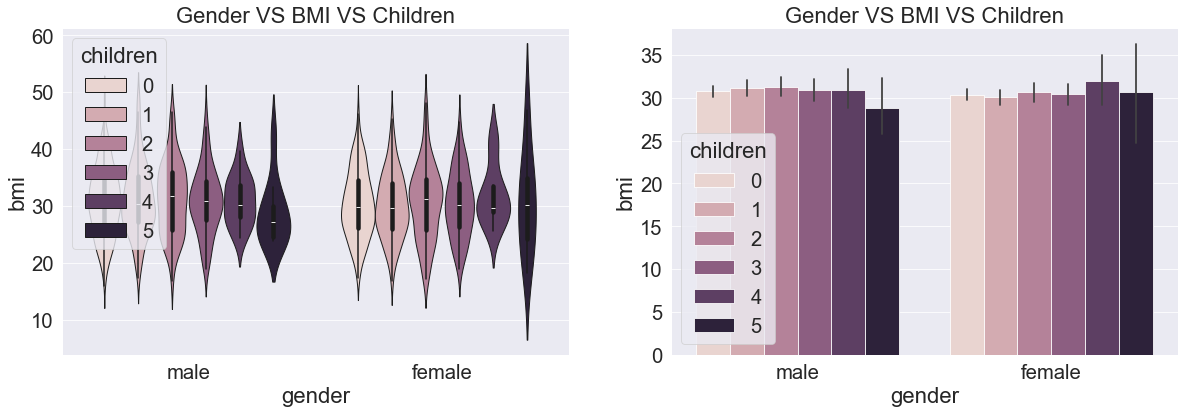

In [123]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['smoker'],ax=ax2)
ax1.set_title('Gender VS BMI VS Smoker')
ax2.set_title('Gender VS BMI VS Smoker')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Gender VS BMI VS Diabetic')
ax2.set_title('Gender VS BMI VS Diabetic')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['region'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['region'],ax=ax2)
ax1.set_title('Gender VS BMI VS Region')
ax2.set_title('Gender VS BMI VS Region')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['children'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['children'],ax=ax2)
ax1.set_title('Gender VS BMI VS Children')
ax2.set_title('Gender VS BMI VS Children');

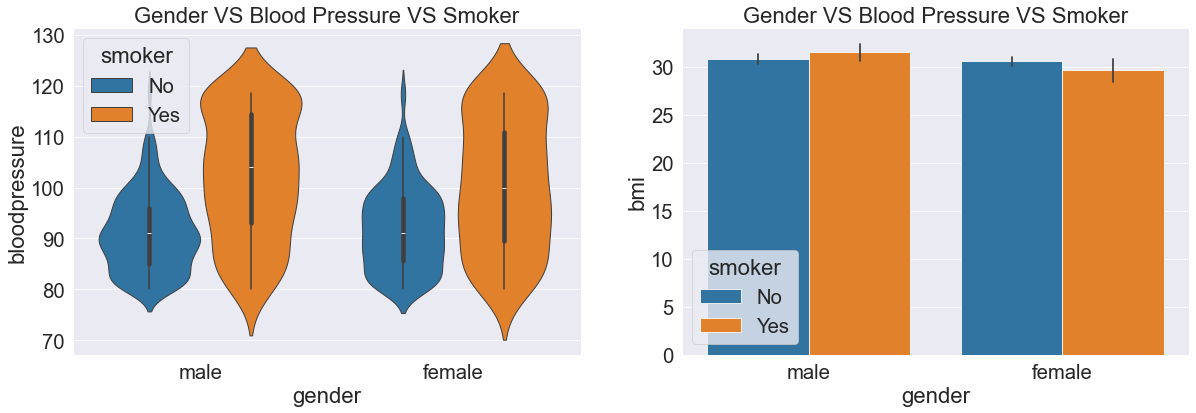

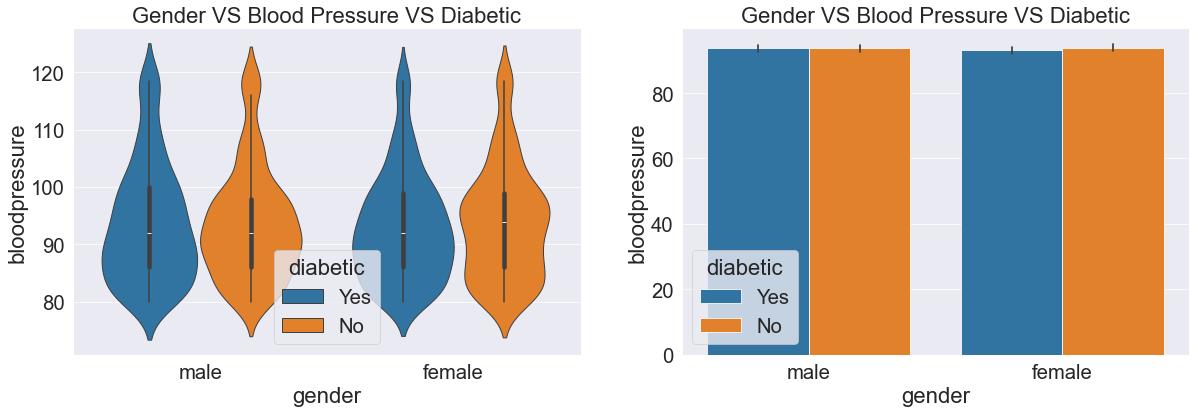

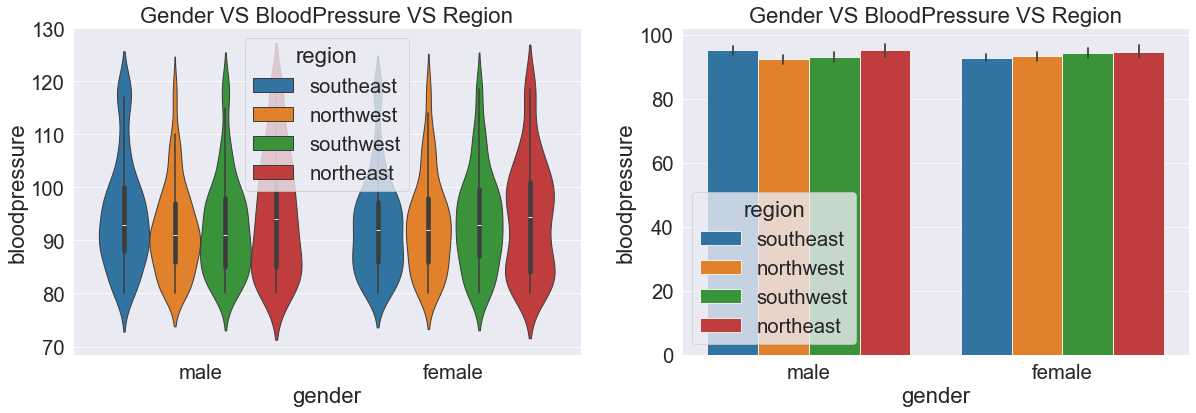

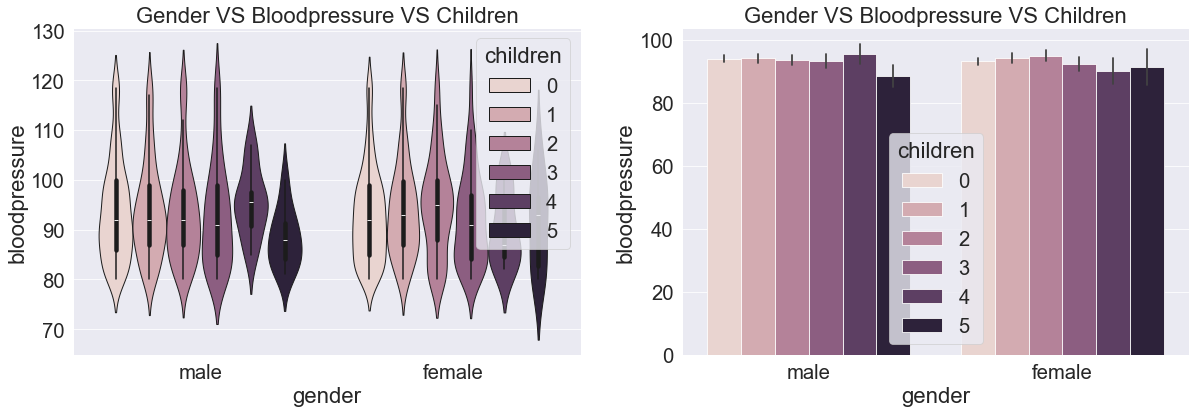

In [124]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['smoker'],ax=ax2)
ax1.set_title('Gender VS Blood Pressure VS Smoker')
ax2.set_title('Gender VS Blood Pressure VS Smoker')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bloodpressure'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Gender VS Blood Pressure VS Diabetic')
ax2.set_title('Gender VS Blood Pressure VS Diabetic')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['region'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bloodpressure'],hue=df['region'],ax=ax2)
ax1.set_title('Gender VS BloodPressure VS Region')
ax2.set_title('Gender VS BloodPressure VS Region')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['children'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bloodpressure'],hue=df['children'],ax=ax2)
ax1.set_title('Gender VS Bloodpressure VS Children')
ax2.set_title('Gender VS Bloodpressure VS Children');

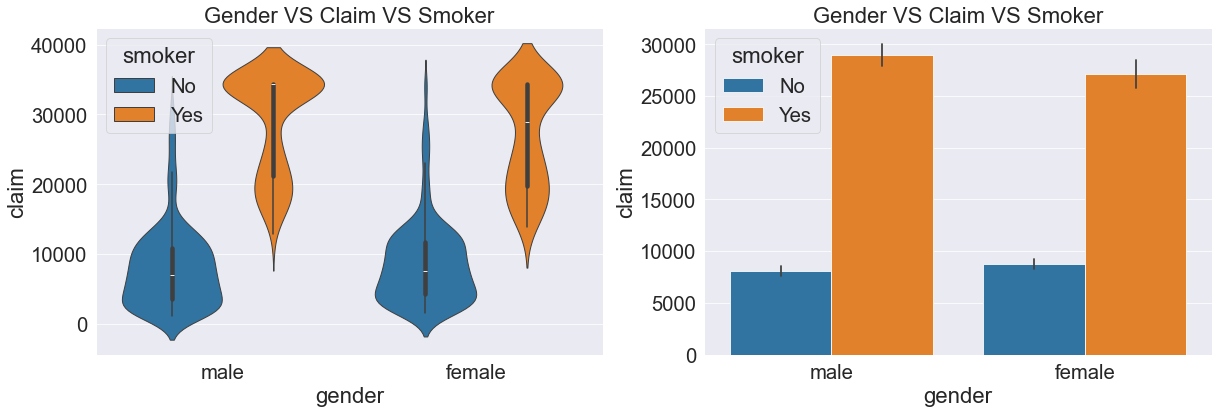

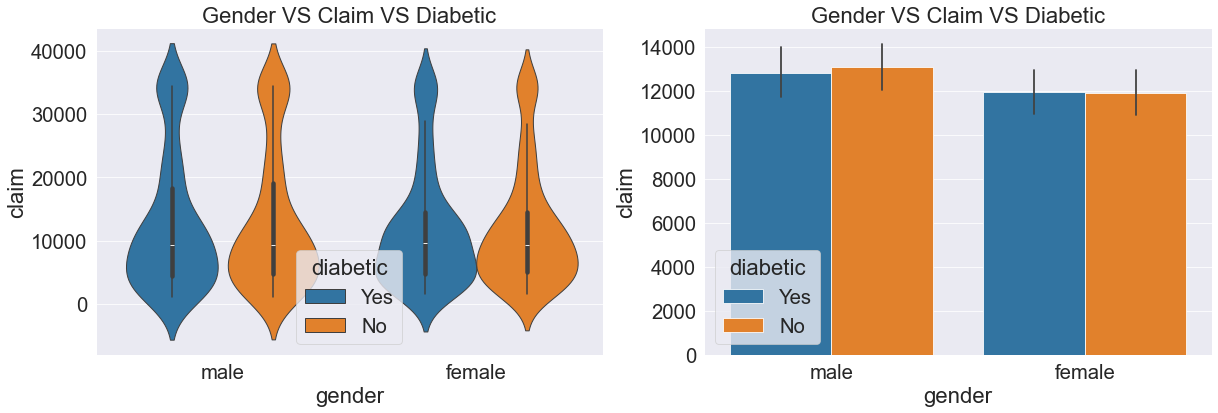

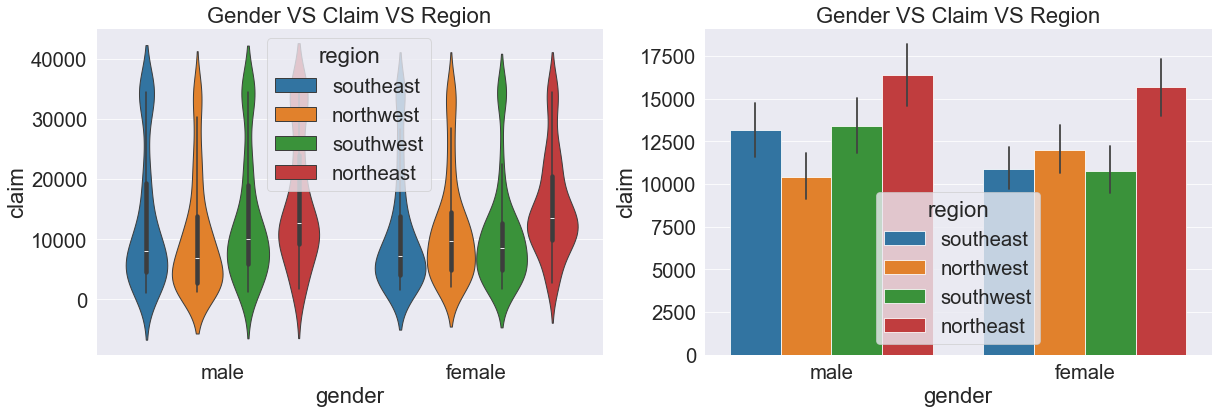

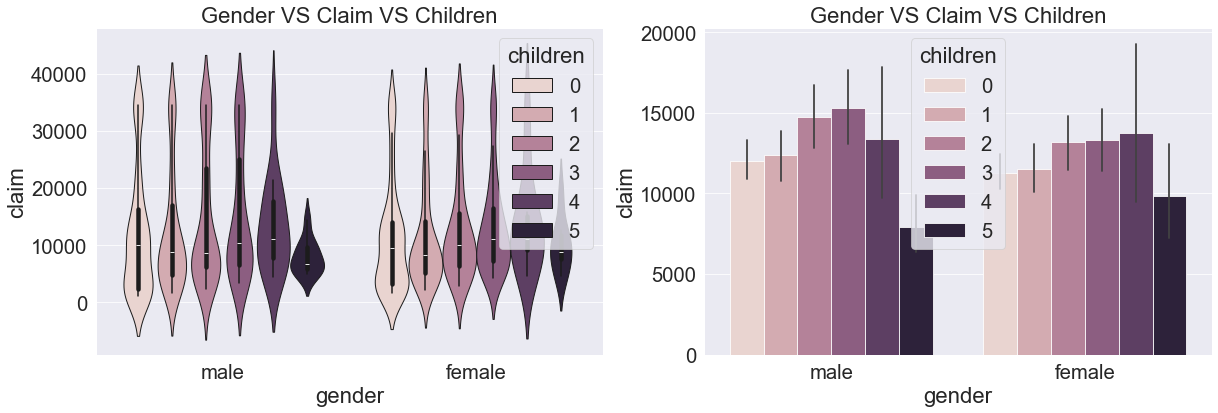

In [125]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['smoker'],ax=ax2)
ax1.set_title('Gender VS Claim VS Smoker')
ax2.set_title('Gender VS Claim VS Smoker')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Gender VS Claim VS Diabetic')
ax2.set_title('Gender VS Claim VS Diabetic')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['region'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['region'],ax=ax2)
ax1.set_title('Gender VS Claim VS Region')
ax2.set_title('Gender VS Claim VS Region')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['children'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['children'],ax=ax2)
ax1.set_title('Gender VS Claim VS Children')
ax2.set_title('Gender VS Claim VS Children');

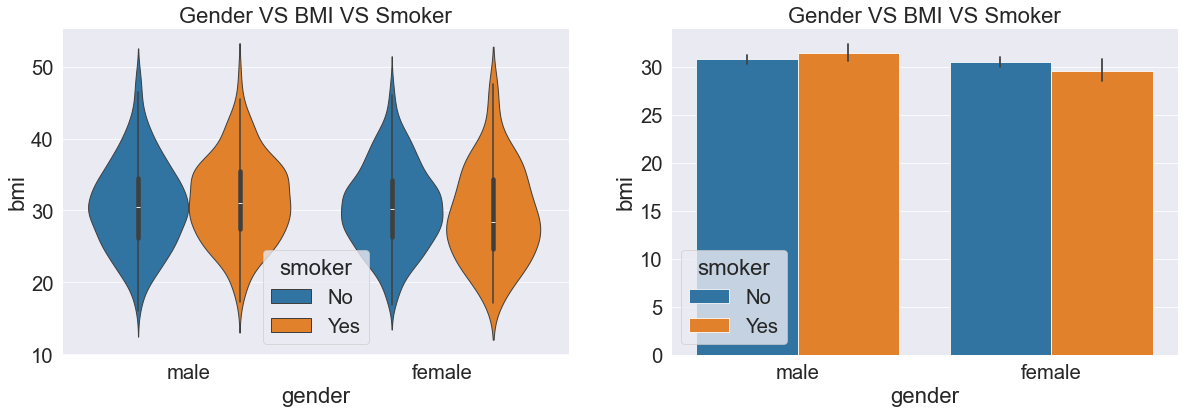

In [126]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['smoker'],ax=ax2)
ax1.set_title('Gender VS BMI VS Smoker')
ax2.set_title('Gender VS BMI VS Smoker');

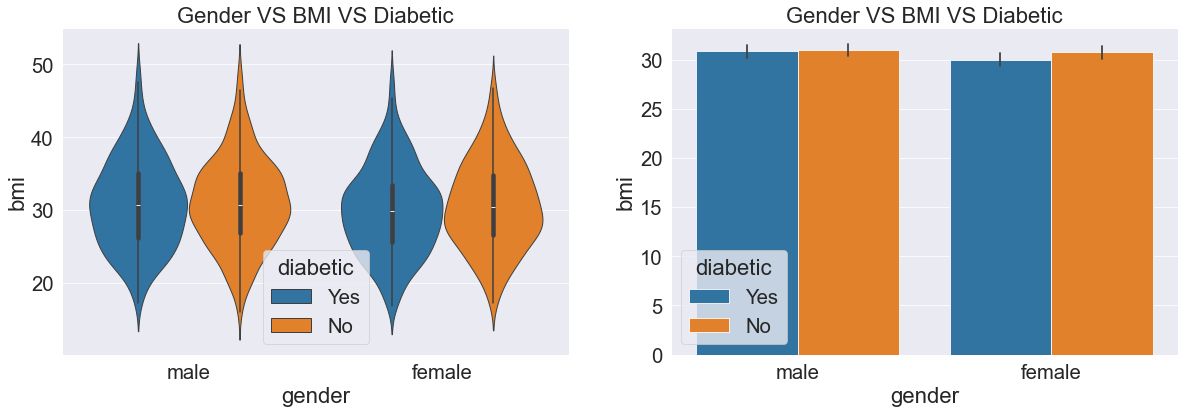

In [127]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Gender VS BMI VS Diabetic')
ax2.set_title('Gender VS BMI VS Diabetic');

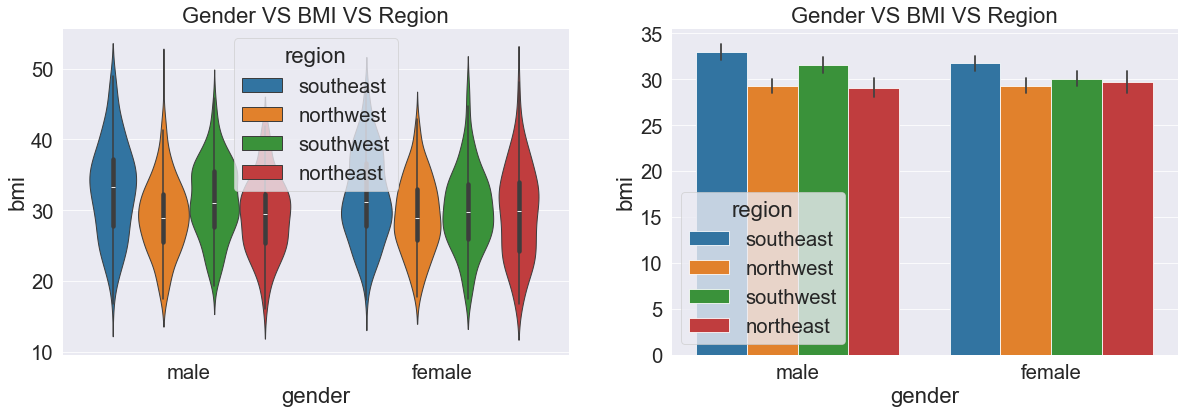

In [128]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bmi'],hue=df['region'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['region'],ax=ax2)
ax1.set_title('Gender VS BMI VS Region')
ax2.set_title('Gender VS BMI VS Region');

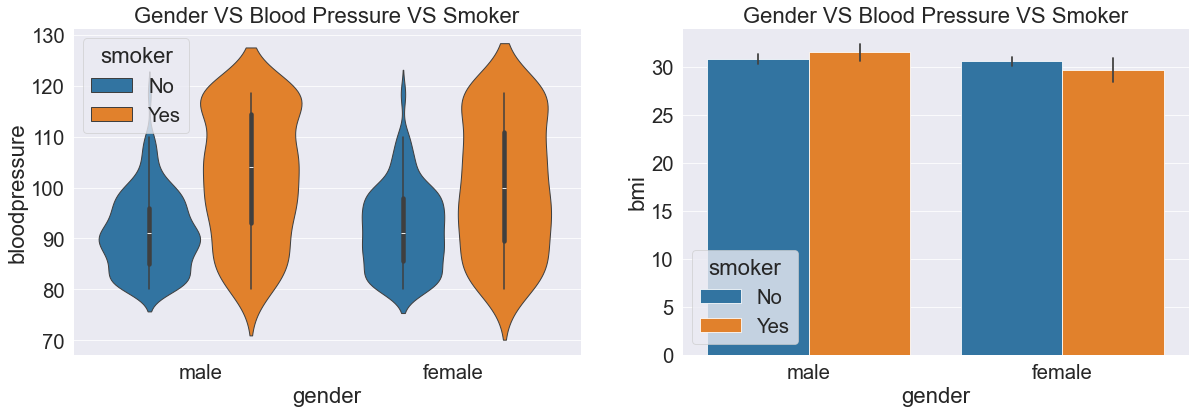

In [129]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bmi'],hue=df['smoker'],ax=ax2)
ax1.set_title('Gender VS Blood Pressure VS Smoker')
ax2.set_title('Gender VS Blood Pressure VS Smoker');

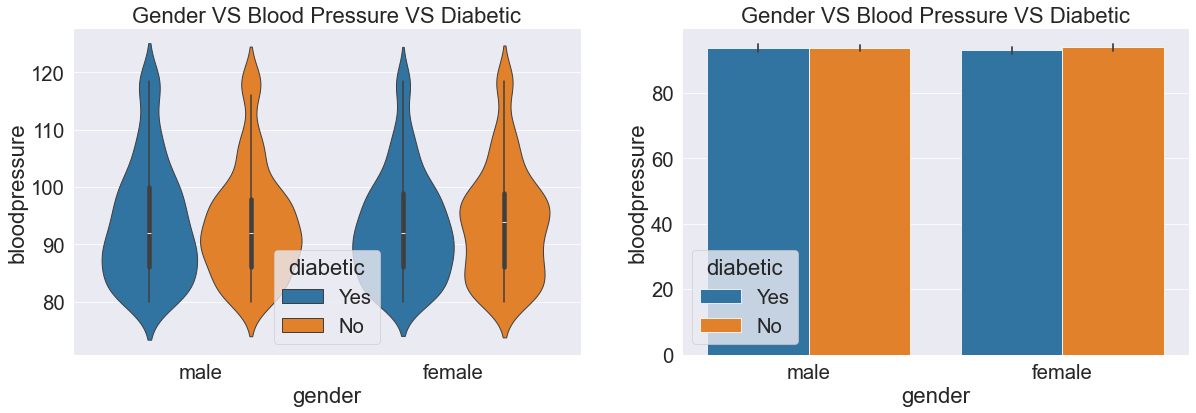

In [130]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bloodpressure'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Gender VS Blood Pressure VS Diabetic')
ax2.set_title('Gender VS Blood Pressure VS Diabetic');

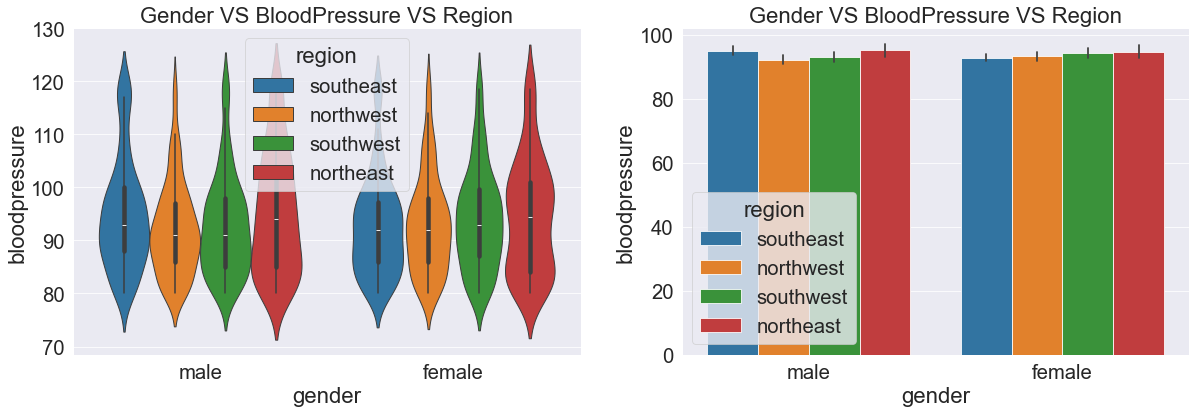

In [131]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['bloodpressure'],hue=df['region'],ax=ax1)
sns.barplot(x=df['gender'],y=df['bloodpressure'],hue=df['region'],ax=ax2)
ax1.set_title('Gender VS BloodPressure VS Region')
ax2.set_title('Gender VS BloodPressure VS Region');

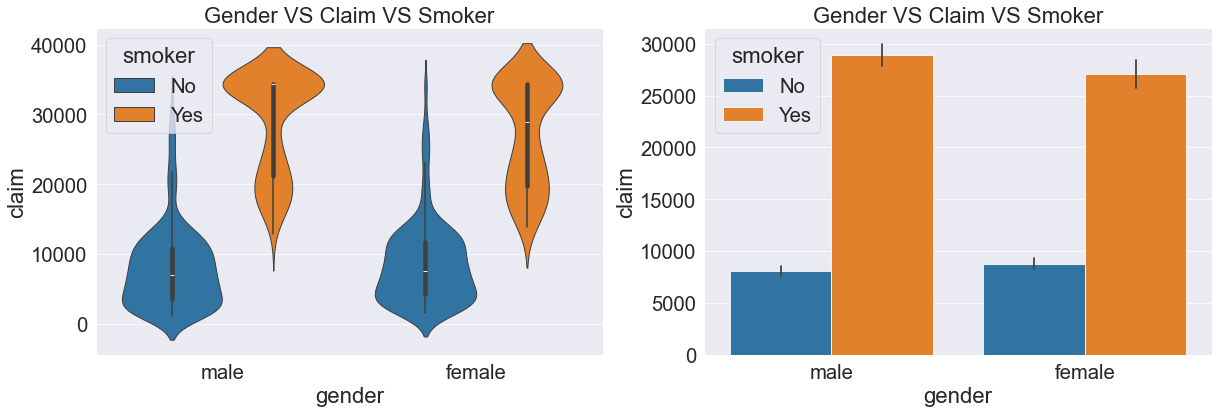

In [132]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['smoker'],ax=ax2)
ax1.set_title('Gender VS Claim VS Smoker')
ax2.set_title('Gender VS Claim VS Smoker');

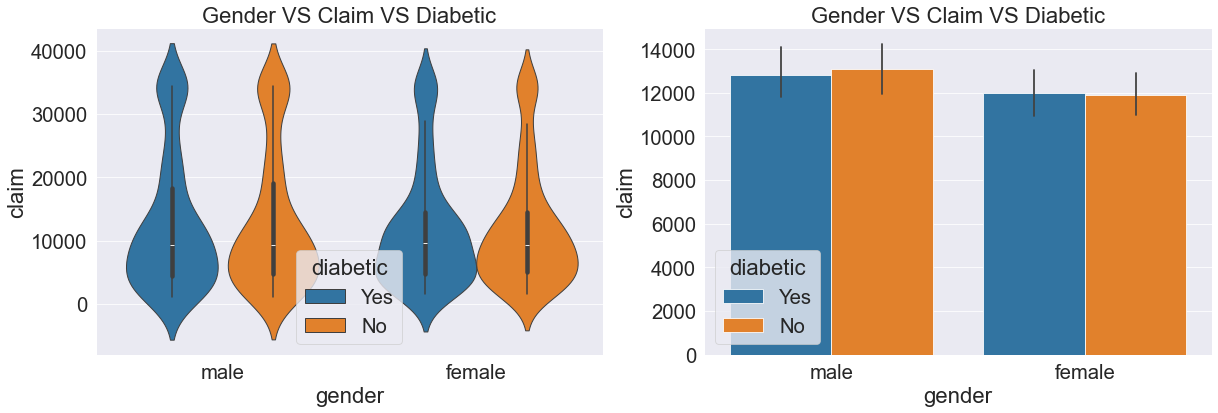

In [133]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Gender VS Claim VS Diabetic')
ax2.set_title('Gender VS Claim VS Diabetic');

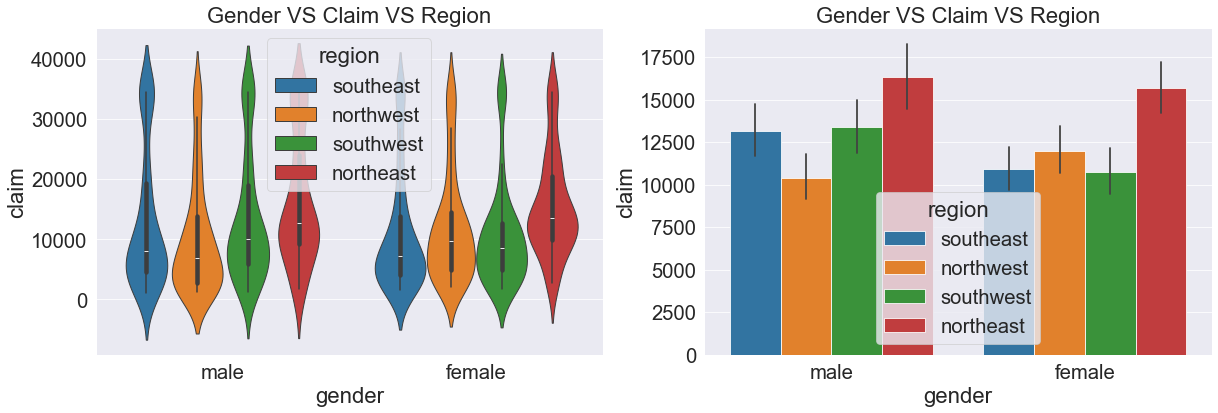

In [134]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['gender'],y=df['claim'],hue=df['region'],ax=ax1)
sns.barplot(x=df['gender'],y=df['claim'],hue=df['region'],ax=ax2)
ax1.set_title('Gender VS Claim VS Region')
ax2.set_title('Gender VS Claim VS Region');

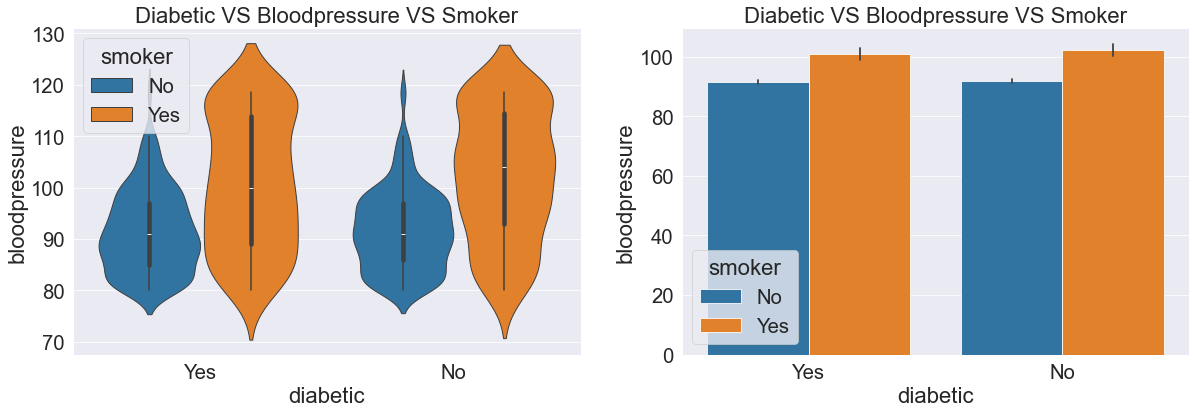

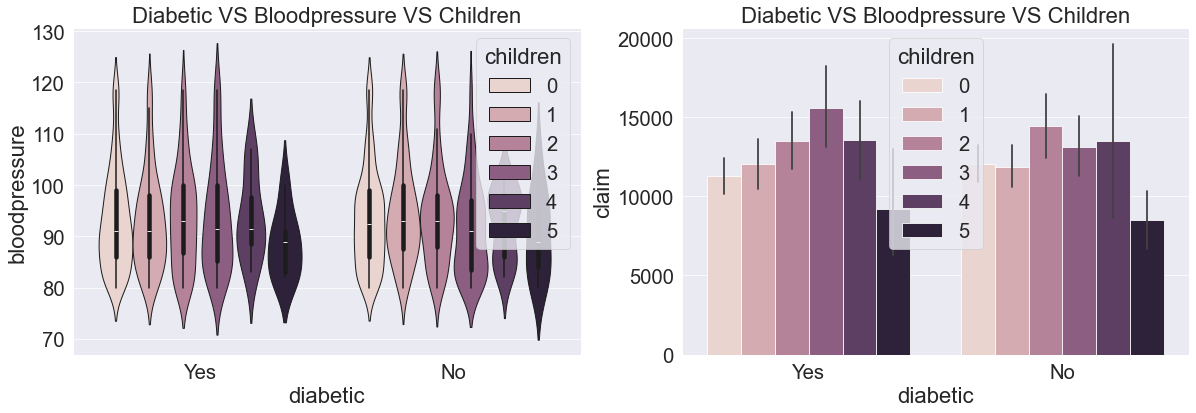

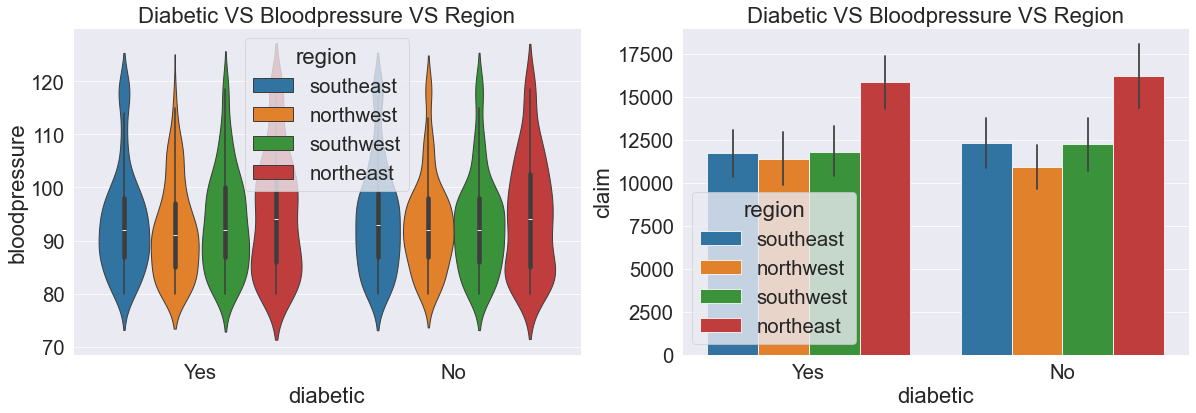

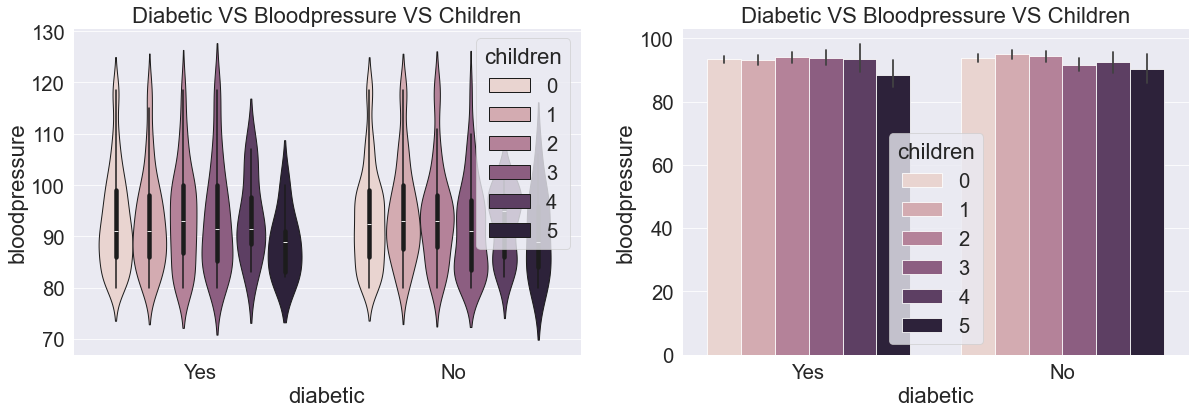

In [135]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bloodpressure'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['bloodpressure'],hue=df['smoker'],ax=ax2)
ax1.set_title('Diabetic VS Bloodpressure VS Smoker')
ax2.set_title('Diabetic VS Bloodpressure VS Smoker')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bloodpressure'],hue=df['children'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['claim'],hue=df['children'],ax=ax2)
ax1.set_title('Diabetic VS Bloodpressure VS Children')
ax2.set_title('Diabetic VS Bloodpressure VS Children')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bloodpressure'],hue=df['region'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['claim'],hue=df['region'],ax=ax2)
ax1.set_title('Diabetic VS Bloodpressure VS Region')
ax2.set_title('Diabetic VS Bloodpressure VS Region')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bloodpressure'],hue=df['children'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['bloodpressure'],hue=df['children'],ax=ax2)
ax1.set_title('Diabetic VS Bloodpressure VS Children')
ax2.set_title('Diabetic VS Bloodpressure VS Children');

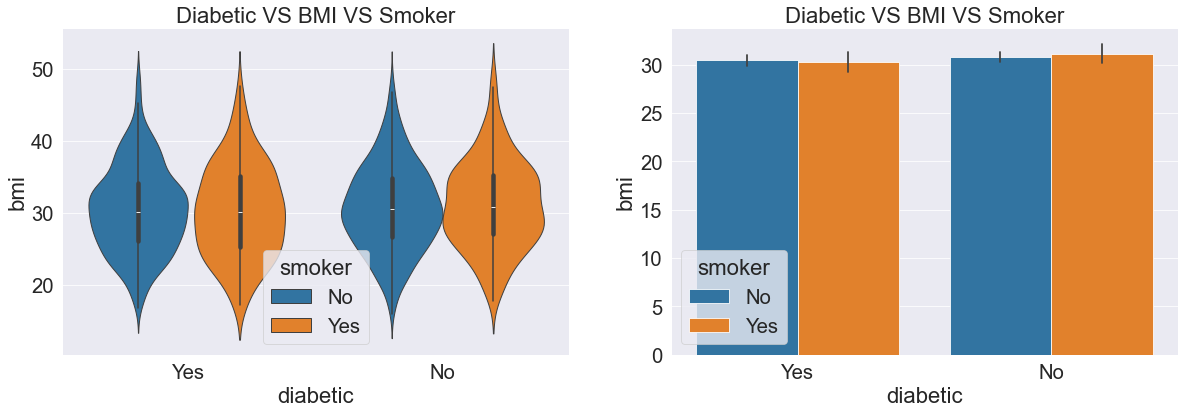

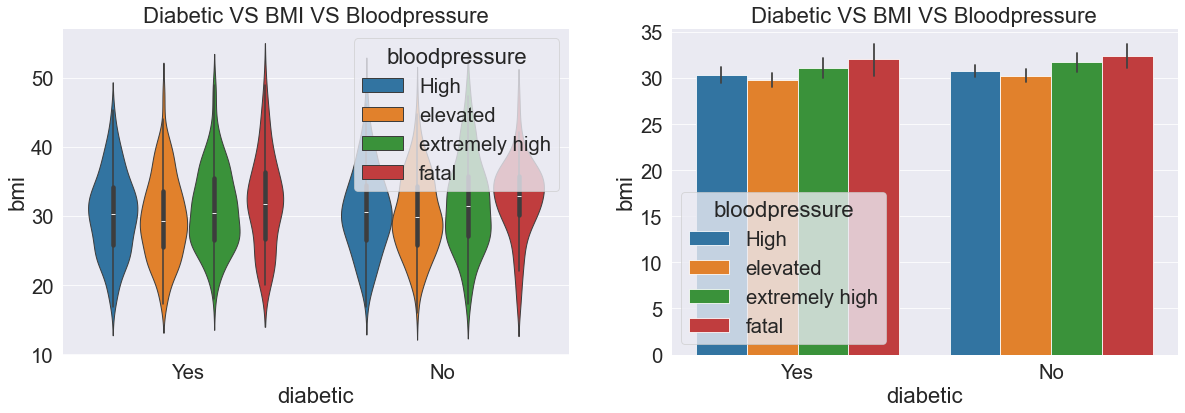

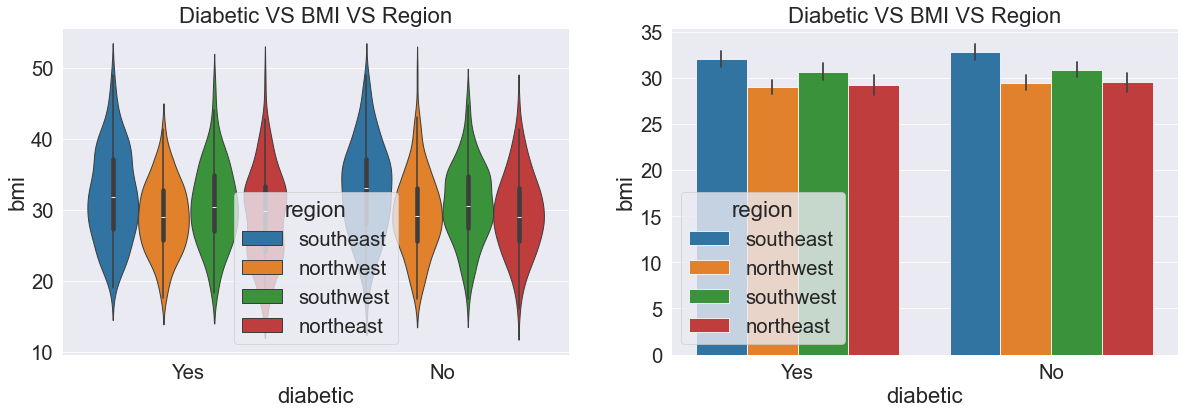

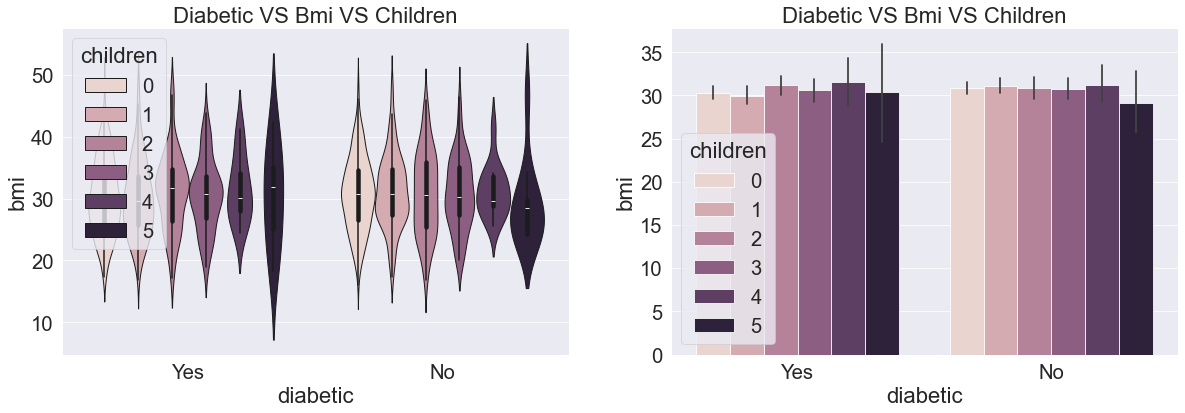

In [136]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bmi'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['bmi'],hue=df['smoker'],ax=ax2)
ax1.set_title('Diabetic VS BMI VS Smoker')
ax2.set_title('Diabetic VS BMI VS Smoker')



fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bmi'],hue=cat_df['bloodpressure'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['bmi'],hue=cat_df['bloodpressure'],ax=ax2)
ax1.set_title('Diabetic VS BMI VS Bloodpressure')
ax2.set_title('Diabetic VS BMI VS Bloodpressure')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bmi'],hue=df['region'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['bmi'],hue=df['region'],ax=ax2)
ax1.set_title('Diabetic VS BMI VS Region')
ax2.set_title('Diabetic VS BMI VS Region')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['bmi'],hue=df['children'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['bmi'],hue=df['children'],ax=ax2)
ax1.set_title('Diabetic VS Bmi VS Children')
ax2.set_title('Diabetic VS Bmi VS Children');

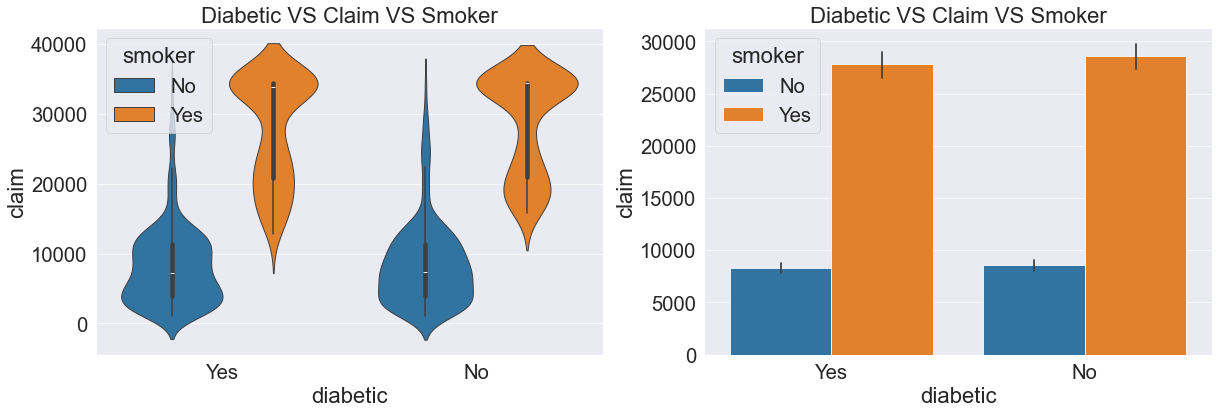

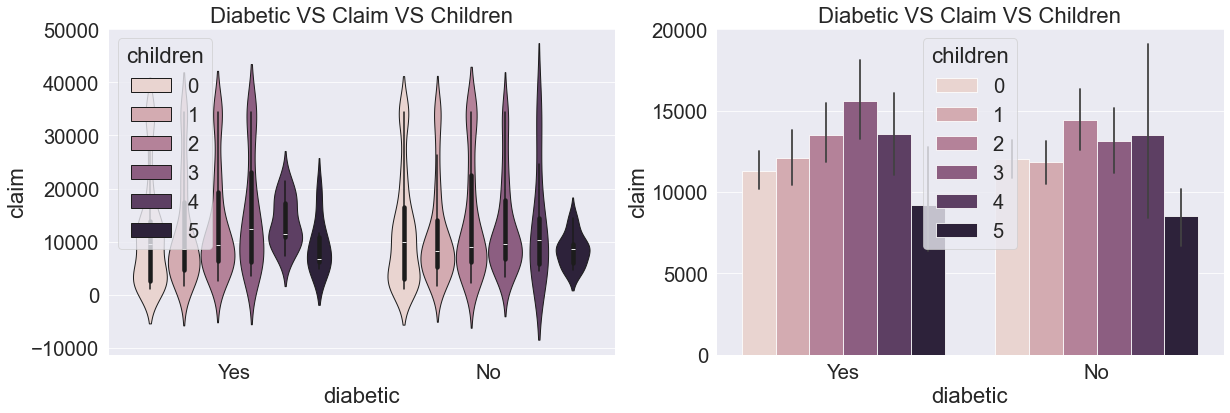

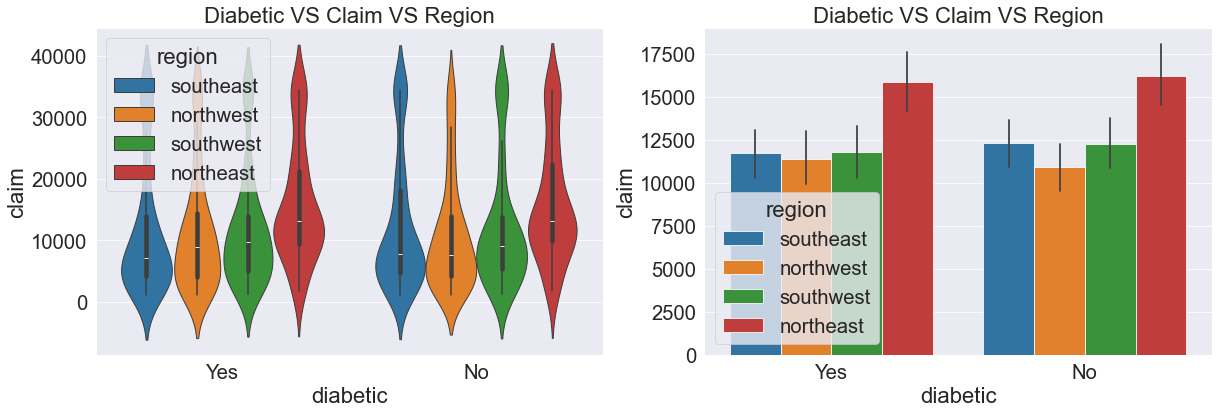

In [137]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['claim'],hue=df['smoker'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['claim'],hue=df['smoker'],ax=ax2)
ax1.set_title('Diabetic VS Claim VS Smoker')
ax2.set_title('Diabetic VS Claim VS Smoker')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['claim'],hue=df['children'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['claim'],hue=df['children'],ax=ax2)
ax1.set_title('Diabetic VS Claim VS Children')
ax2.set_title('Diabetic VS Claim VS Children')

fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=df['diabetic'],y=df['claim'],hue=df['region'],ax=ax1)
sns.barplot(x=df['diabetic'],y=df['claim'],hue=df['region'],ax=ax2)
ax1.set_title('Diabetic VS Claim VS Region')
ax2.set_title('Diabetic VS Claim VS Region');

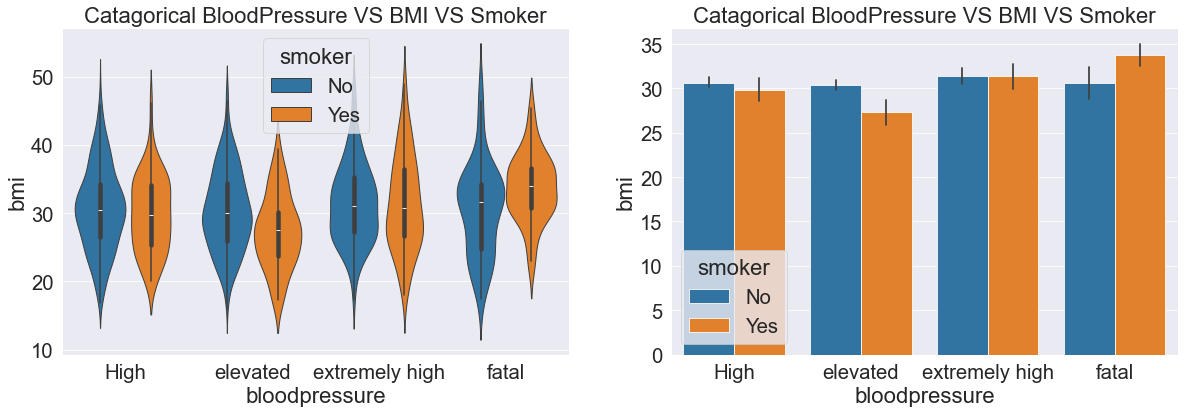

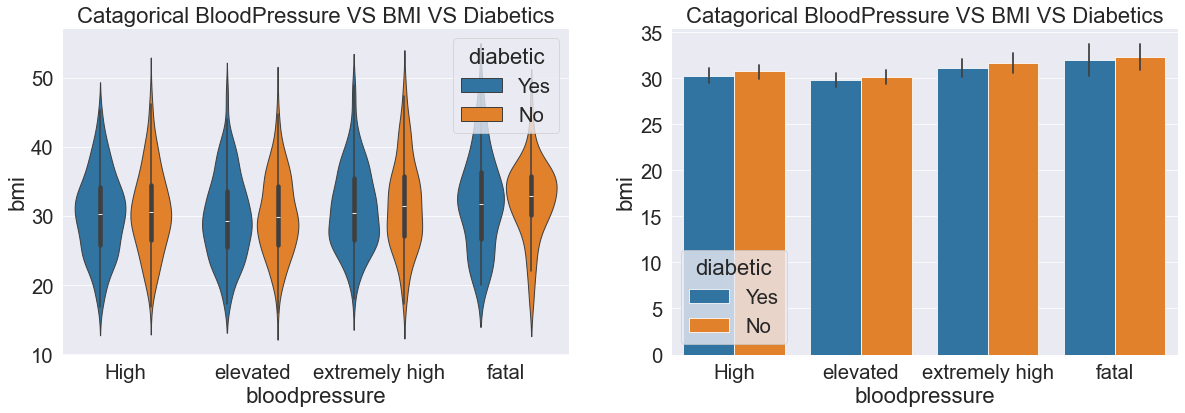

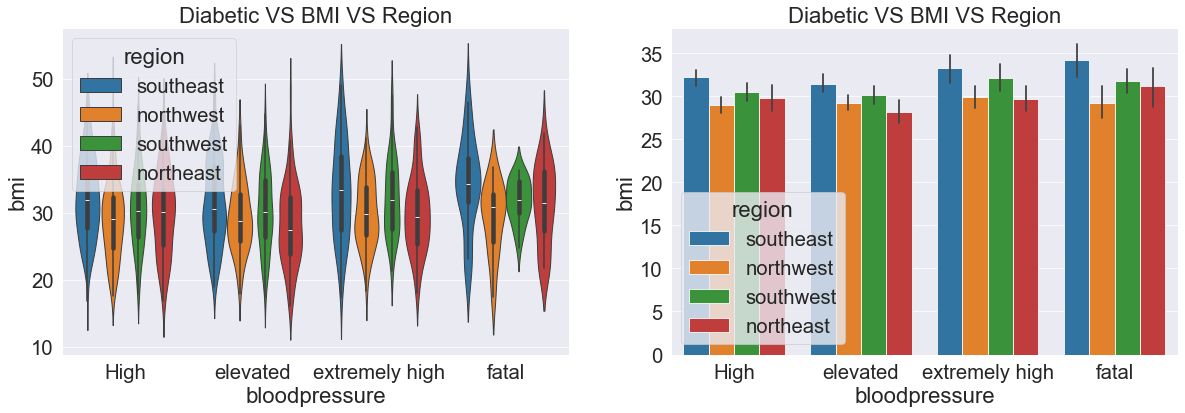

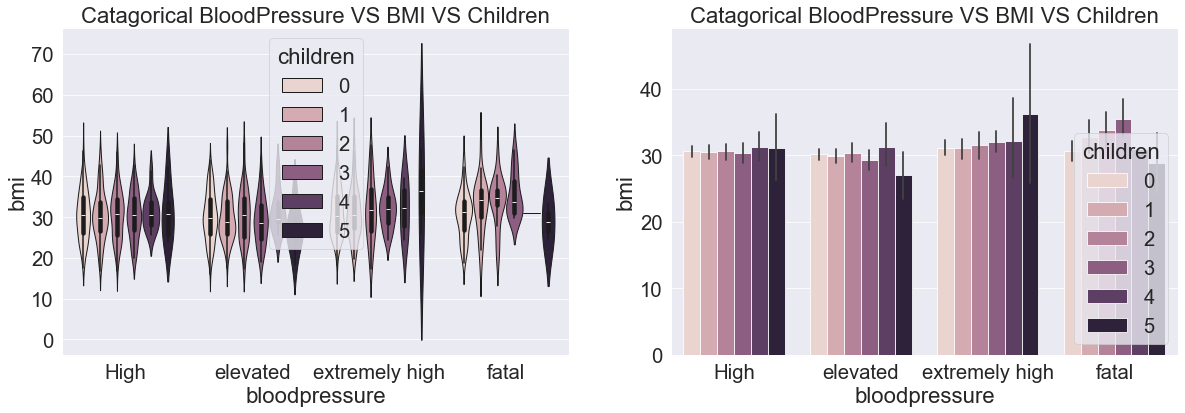

In [138]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['smoker'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['smoker'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS BMI VS Smoker')
ax2.set_title('Catagorical BloodPressure VS BMI VS Smoker')



fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS BMI VS Diabetics')
ax2.set_title('Catagorical BloodPressure VS BMI VS Diabetics')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['region'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['region'],ax=ax2)
ax1.set_title('Diabetic VS BMI VS Region')
ax2.set_title('Diabetic VS BMI VS Region')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['children'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['bmi'],hue=df['children'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS BMI VS Children')
ax2.set_title('Catagorical BloodPressure VS BMI VS Children');

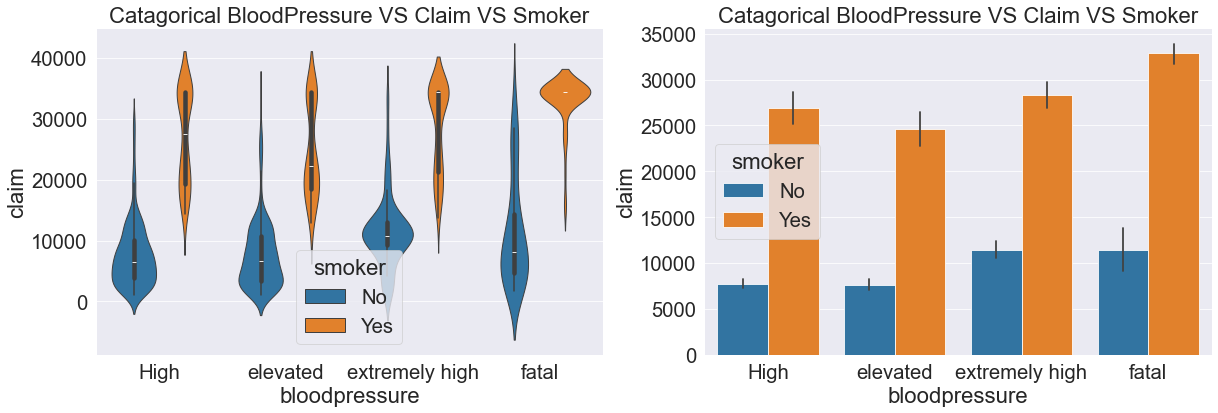

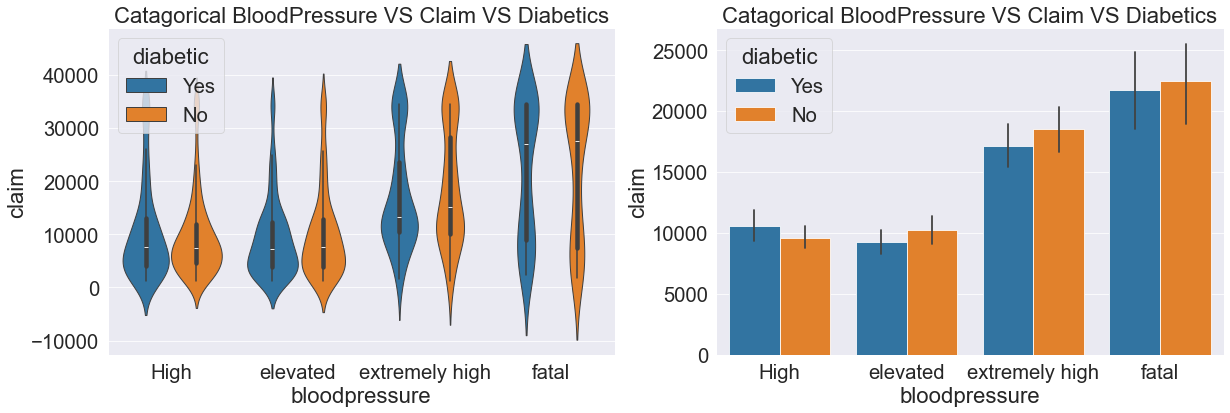

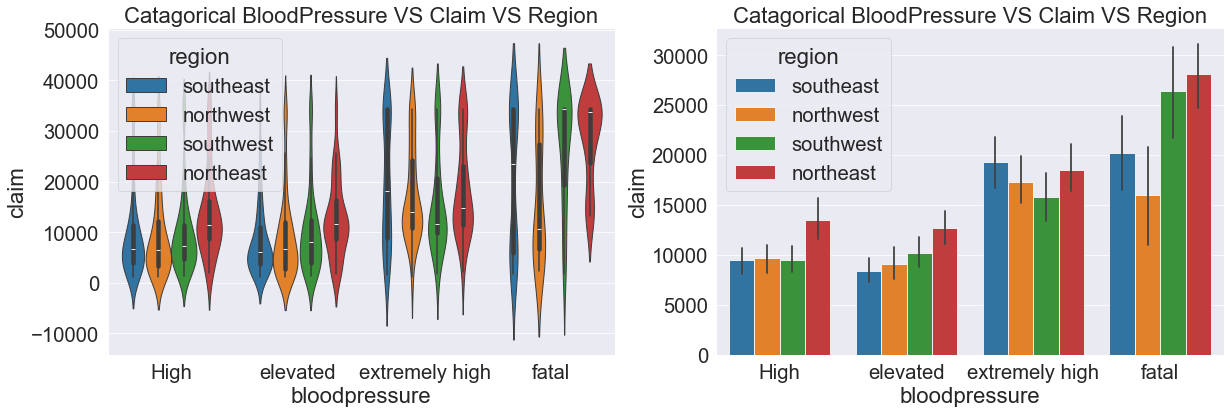

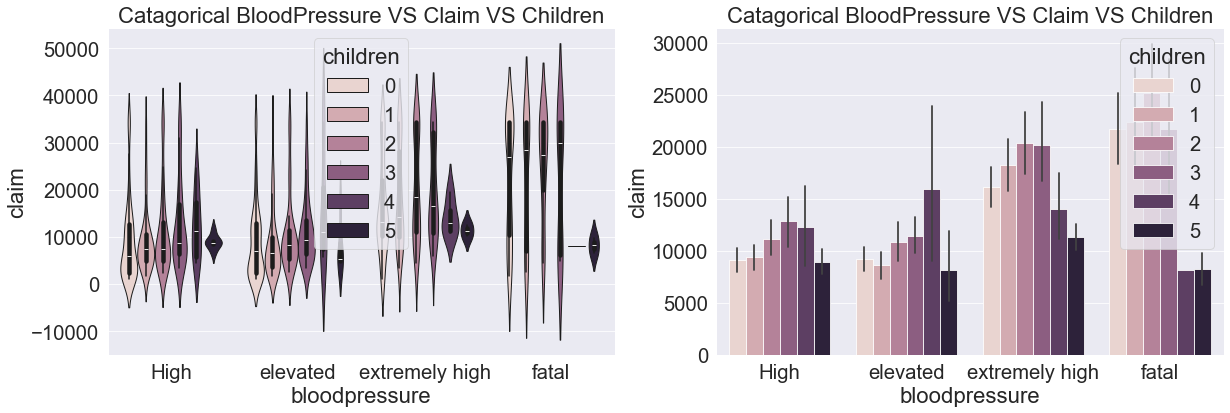

In [139]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['smoker'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['smoker'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS Claim VS Smoker')
ax2.set_title('Catagorical BloodPressure VS Claim VS Smoker')



fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS Claim VS Diabetics')
ax2.set_title('Catagorical BloodPressure VS Claim VS Diabetics')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['region'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['region'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS Claim VS Region')
ax2.set_title('Catagorical BloodPressure VS Claim VS Region')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['children'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['children'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS Claim VS Children')
ax2.set_title('Catagorical BloodPressure VS Claim VS Children');

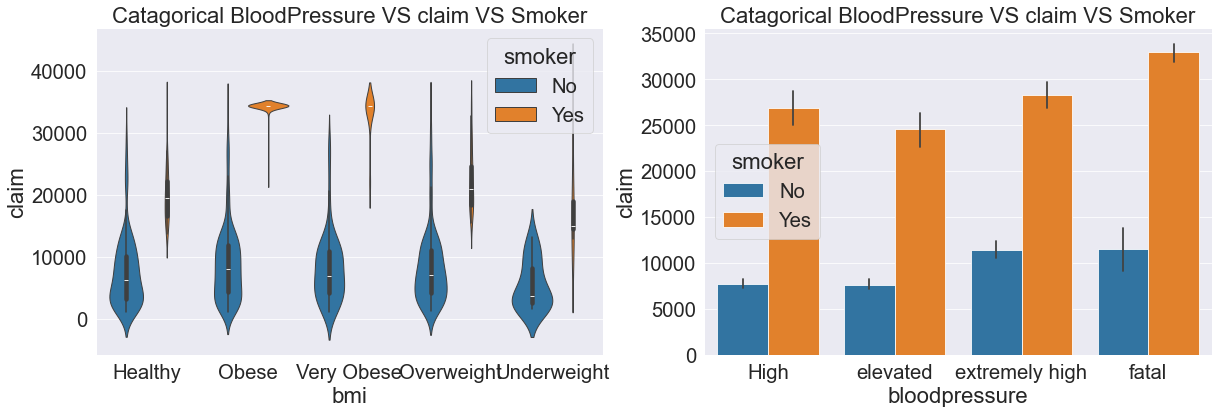

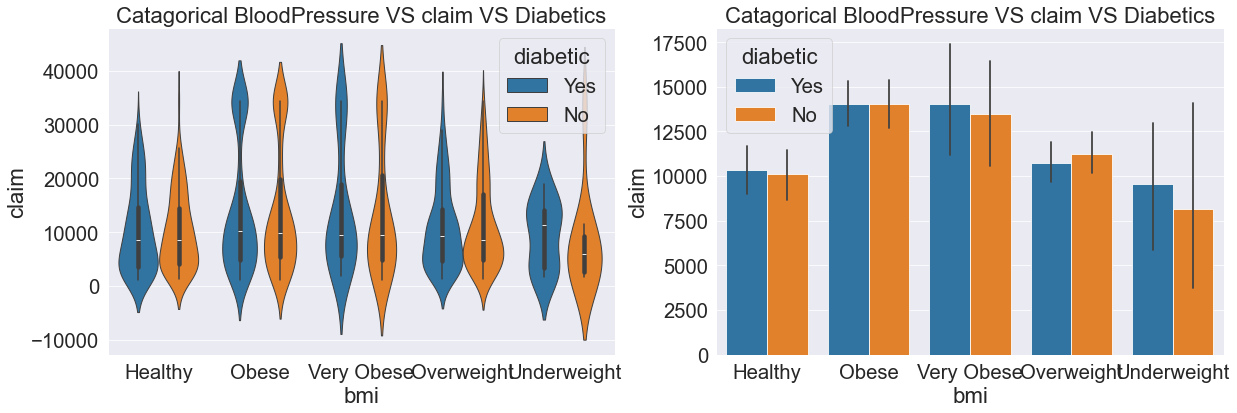

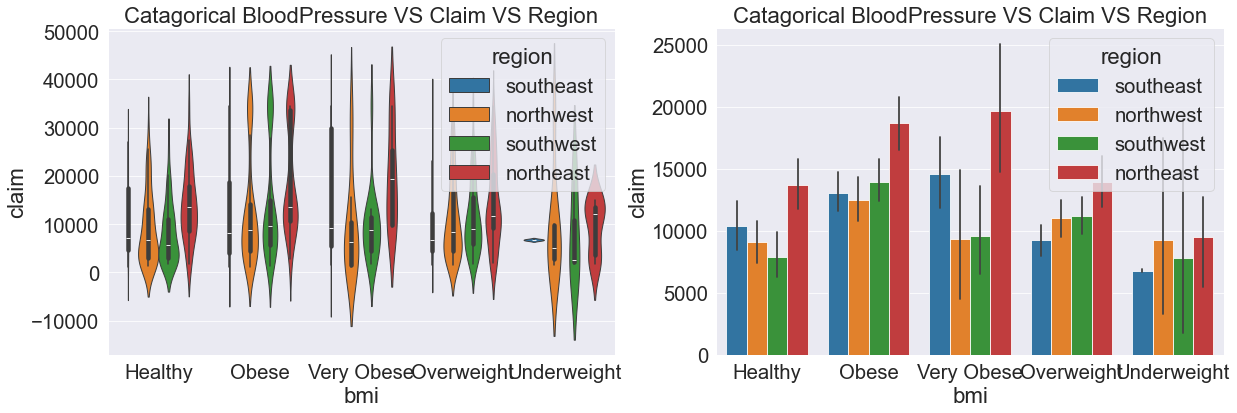

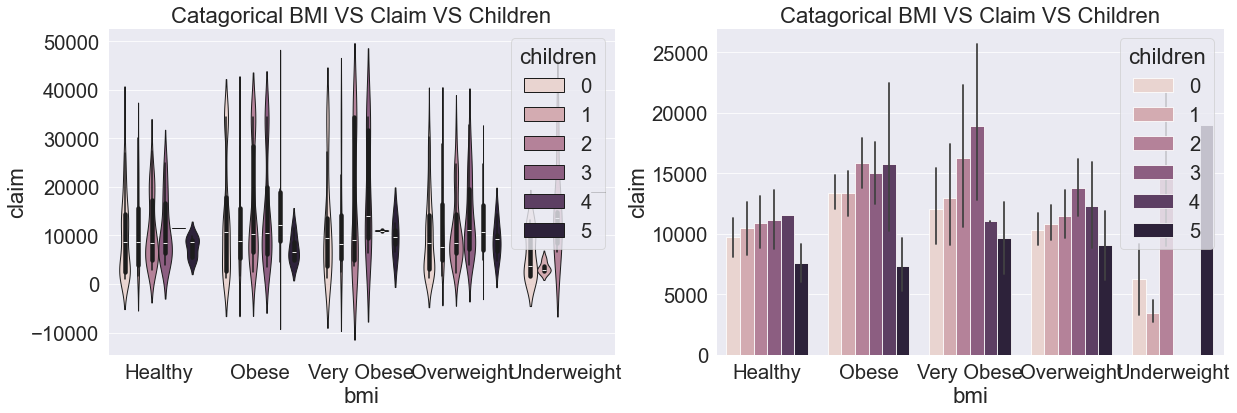

In [140]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bmi'],y=df['claim'],hue=df['smoker'],ax=ax1)
sns.barplot(x=cat_df['bloodpressure'],y=df['claim'],hue=df['smoker'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS claim VS Smoker')
ax2.set_title('Catagorical BloodPressure VS claim VS Smoker')



fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bmi'],y=df['claim'],hue=df['diabetic'],ax=ax1)
sns.barplot(x=cat_df['bmi'],y=df['claim'],hue=df['diabetic'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS claim VS Diabetics')
ax2.set_title('Catagorical BloodPressure VS claim VS Diabetics')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bmi'],y=df['claim'],hue=df['region'],ax=ax1)
sns.barplot(x=cat_df['bmi'],y=df['claim'],hue=df['region'],ax=ax2)
ax1.set_title('Catagorical BloodPressure VS Claim VS Region')
ax2.set_title('Catagorical BloodPressure VS Claim VS Region')


fig = plt.figure(figsize=(20,6))
(ax1,ax2) = fig.subplots(1,2)
sns.violinplot(x=cat_df['bmi'],y=df['claim'],hue=df['children'],ax=ax1)
sns.barplot(x=cat_df['bmi'],y=df['claim'],hue=df['children'],ax=ax2)
ax1.set_title('Catagorical BMI VS Claim VS Children')
ax2.set_title('Catagorical BMI VS Claim VS Children');

### Num to Num Features

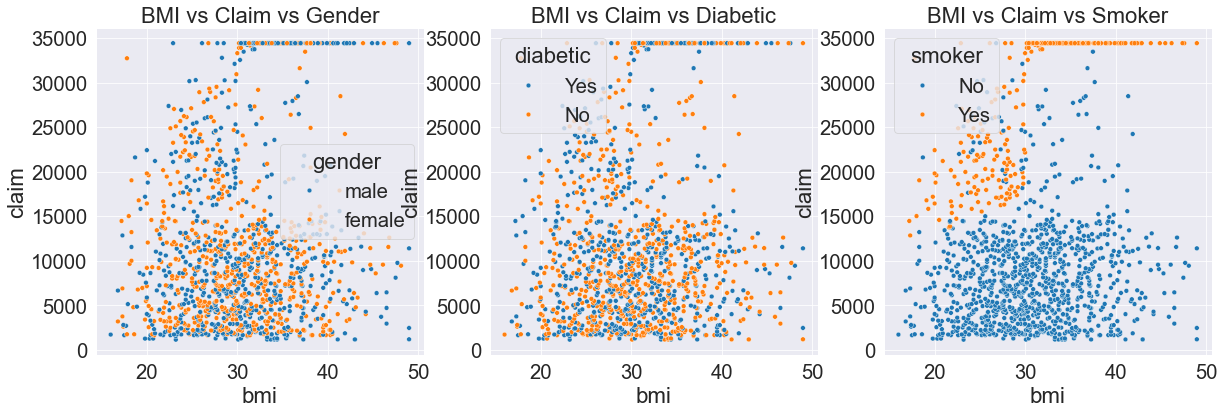

In [141]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2,ax3) = fig.subplots(1,3)
sns.scatterplot(x=df['bmi'],y=df['claim'],hue=df['gender'],ax=ax1)
ax1.set_title('BMI vs Claim vs Gender')

sns.scatterplot(x=df['bmi'],y=df['claim'],hue=df['diabetic'],ax=ax2)
ax2.set_title('BMI vs Claim vs Diabetic')

sns.scatterplot(x=df['bmi'],y=df['claim'],hue=df['smoker'],ax=ax3)
ax3.set_title('BMI vs Claim vs Smoker');

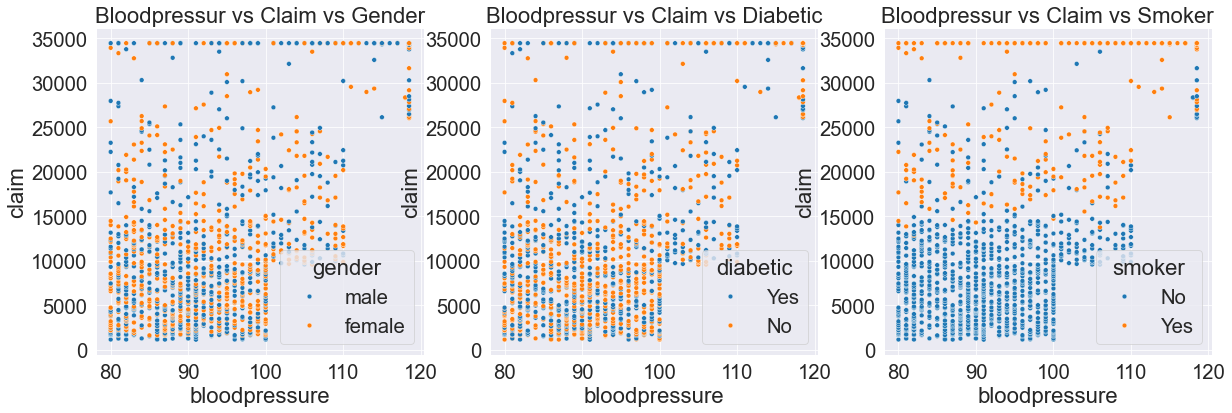

In [142]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2,ax3) = fig.subplots(1,3)
sns.scatterplot(x=df['bloodpressure'],y=df['claim'],hue=df['gender'],ax=ax1)
ax1.set_title('Bloodpressur vs Claim vs Gender')
sns.scatterplot(x=df['bloodpressure'],y=df['claim'],hue=df['diabetic'],ax=ax2)
ax2.set_title('Bloodpressur vs Claim vs Diabetic')

sns.scatterplot(x=df['bloodpressure'],y=df['claim'],hue=df['smoker'],ax=ax3);
ax3.set_title('Bloodpressur vs Claim vs Smoker');

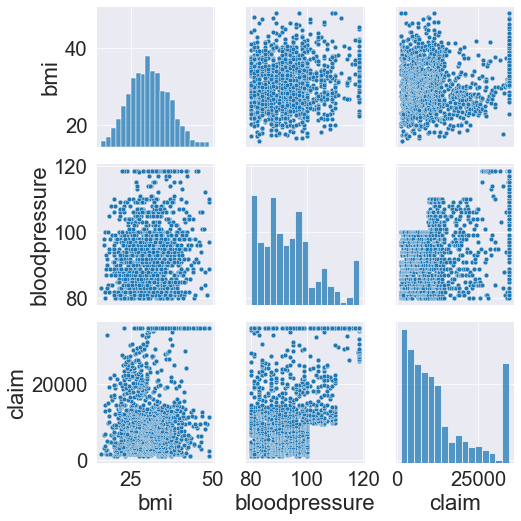

In [143]:
 sns.pairplot(df[['bmi','bloodpressure','claim']]);

In [144]:
df[['bmi','bloodpressure','claim']].corr()

,bmi,bloodpressure,claim
bmi,1.000000,0.141027,0.159282
bloodpressure,0.141027,1.000000,0.507597
claim,0.159282,0.507597,1.000000


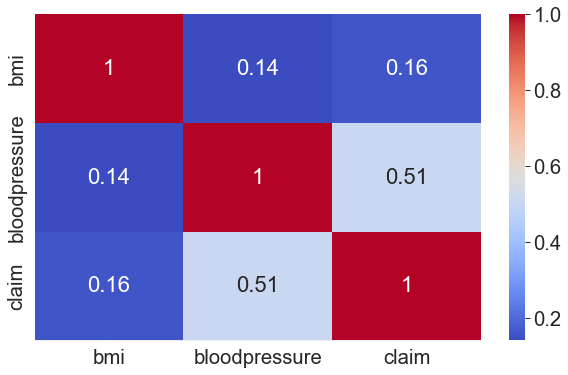

In [145]:
sns.heatmap(df[['bmi','bloodpressure','claim']].corr(),annot=True,cmap='coolwarm');

In [146]:
df.head(1)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,39.0,male,23.2,91.0,Yes,0,No,southeast,1121.87


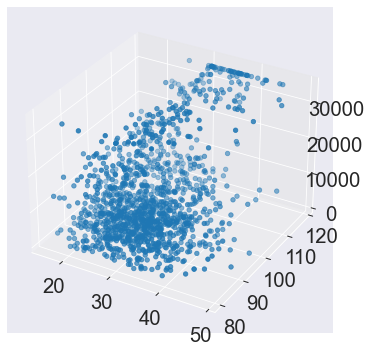

In [147]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['bmi'],df['bloodpressure'],df['claim']);

### Feature Engineering

In [148]:
from sklearn.preprocessing import FunctionTransformer

### Log Transformation

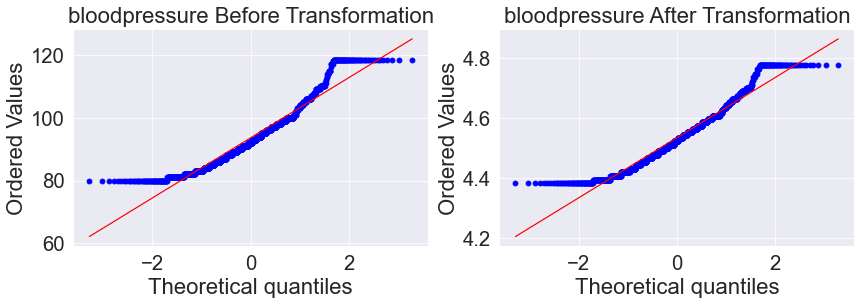

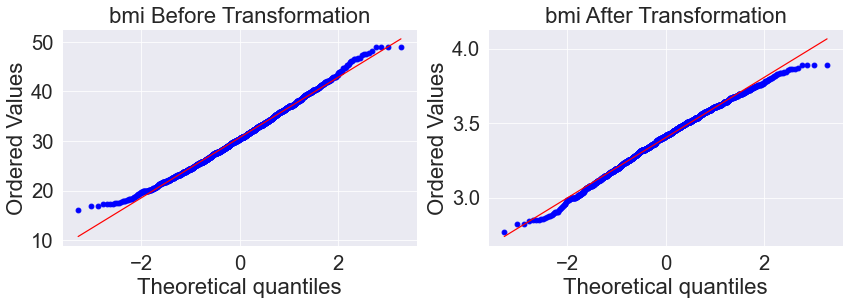

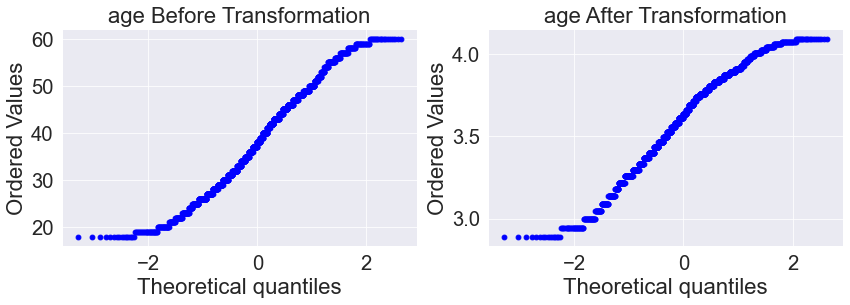

In [149]:
from copy import deepcopy 
def log_transformation(val):
    return np.log(val)
import scipy.stats as stats
num_cols = ['bloodpressure','bmi','age']
temp_df = deepcopy (df)
for col in num_cols:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'{col} Before Transformation')    
    
    temp_df[col] = df[col].apply(log_transformation)
    
    plt.subplot(122)
    stats.probplot(temp_df[col], dist="norm", plot=plt)
    plt.title(f'{col} After Transformation')
    plt.show();    

### Feature Scalling 

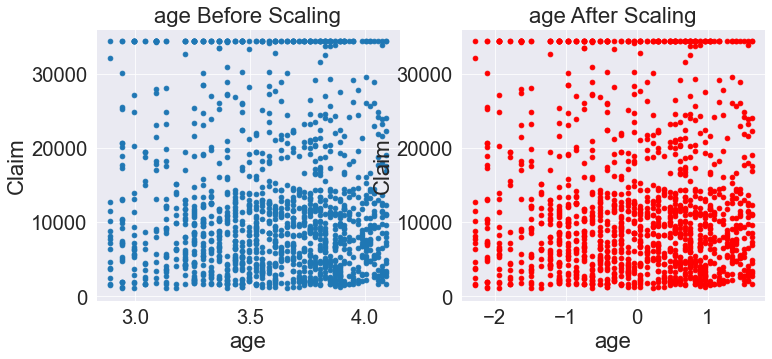

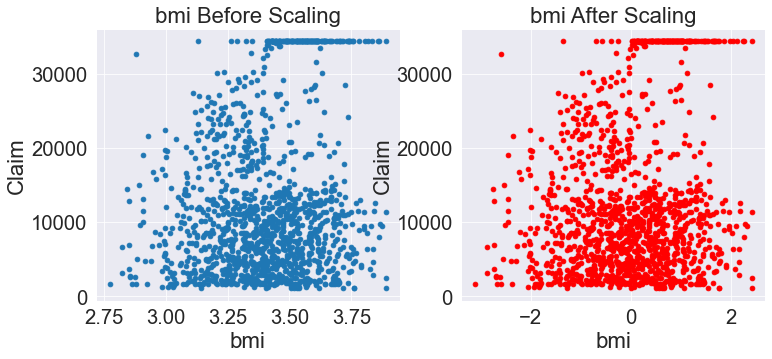

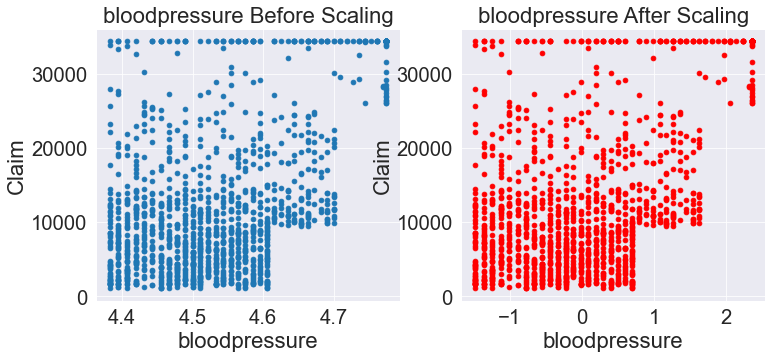

In [150]:
num_cols = ['age','bmi','bloodpressure']
for col in num_cols:
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
    ax1.scatter(temp_df[col], temp_df['claim'])
    ax1.set_title(f"{col} Before Scaling") 
    ax1.set_xlabel(f"{col}") 
    ax1.set_ylabel("Claim") 
    scaler = StandardScaler()
    scaler.fit(temp_df[[col]]) 
    temp_df[col] = scaler.transform(temp_df[[col]])
    ax2.scatter(temp_df[col], temp_df['claim'],color='red')
    ax2.set_title(f"{col} After Scaling")
    ax2.set_xlabel(f"{col}") 
    ax2.set_ylabel("Claim") 
    plt.show();

### Model Building and Training

In [151]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [152]:
# Splitting the data
X = temp_df.drop(columns=['claim'])
y = temp_df[['claim']]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [153]:
# Categorical columns and preprocessor
numeric_cols = [0,2,3]
categorical_cols = [1,4,6,7]
# Defining the pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse=False,drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Creating the pipeline with preprocessing and linear regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])



In [154]:
x_train = pipeline.fit_transform(x_train)
x_test = pipeline.transform(x_test)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [155]:
model = LinearRegression()

In [156]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

### Evaluating the model

In [157]:
def r2_adjusted_score(r2,rows,cols):
    return 1 - ( ((1-r2)*(rows-1))/(rows-1-cols))

In [158]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
Adjusted_R2_Score = r2_adjusted_score(r2,x_train.shape[0],x_train.shape[1])

### Displaying the evaluation metrics

In [159]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Adjusted R2 squared:", Adjusted_R2_Score)

Mean Absolute Error: 3976.6700154514124
Mean Squared Error: 28248249.95029035
Root Mean Squared Error: 5314.908272989323
R-squared: 0.7420951073799544
Adjusted R2 squared: 0.7399094726967337


# Assumptions of Linear Regression

### 1. Linear Relationship

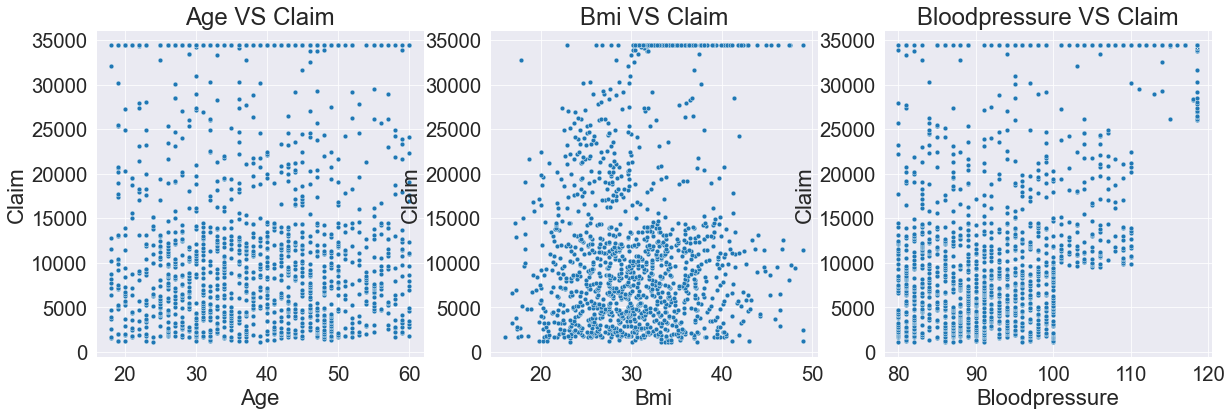

In [160]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2,ax3) = fig.subplots(1,3)
sns.scatterplot(x=df['age'],y=df['claim'],ax=ax1)
ax1.set_xlabel('Age')
ax1.set_ylabel('Claim')
ax1.set_title('Age VS Claim', fontsize=24, loc='center');

sns.scatterplot(x=df['bmi'],y=df['claim'],ax=ax2);
ax2.set_xlabel('Bmi')
ax2.set_ylabel('Claim')
ax2.set_title('Bmi VS Claim', fontsize=24, loc='center');

sns.scatterplot(x=df['bloodpressure'],y=df['claim'],ax=ax3);
ax3.set_xlabel('Bloodpressure')
ax3.set_ylabel('Claim')
ax3.set_title('Bloodpressure VS Claim', fontsize=24, loc='center');

### 2. Multicollinearity

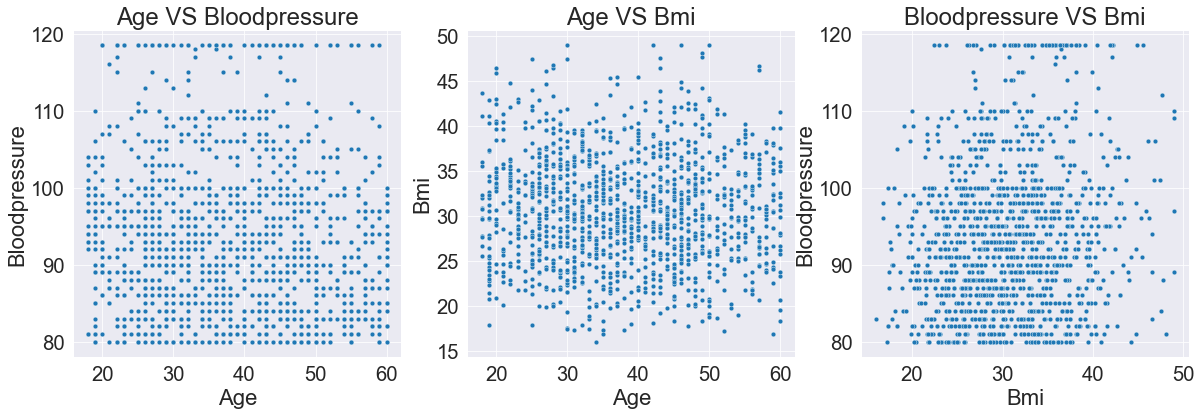

In [161]:
fig = plt.figure(figsize=(20,6))
(ax1,ax2,ax3) = fig.subplots(1,3)
sns.scatterplot(x=df['age'],y=df['bloodpressure'],ax=ax1);
ax1.set_xlabel('Age')
ax1.set_ylabel('Bloodpressure')
ax1.set_title('Age VS Bloodpressure', fontsize=24, loc='center')

sns.scatterplot(x=df['age'],y=df['bmi'],ax=ax2);
ax2.set_xlabel('Age')
ax2.set_ylabel('Bmi')
ax2.set_title('Age VS Bmi', fontsize=24, loc='center')

sns.scatterplot(x=df['bmi'],y=df['bloodpressure']);
ax3.set_xlabel('Bmi')
ax3.set_ylabel('Bloodpressure')
ax3.set_title('Bloodpressure VS Bmi', fontsize=24, loc='center');

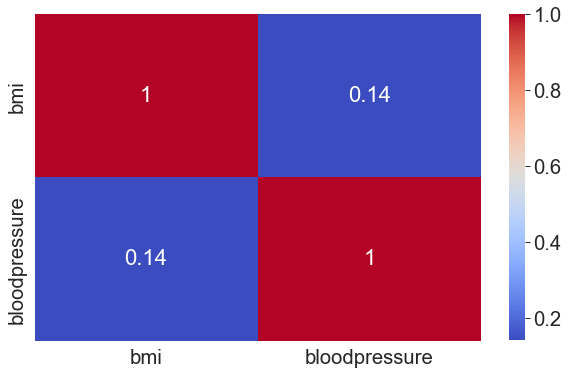

In [162]:
sns.heatmap(df[['bmi','bloodpressure']].corr(),annot=True,cmap='coolwarm');

> <h4>There is No Correlation between Input Features</h4>

### 3. Normality of Residual

In [163]:
residual = y_test - y_pred

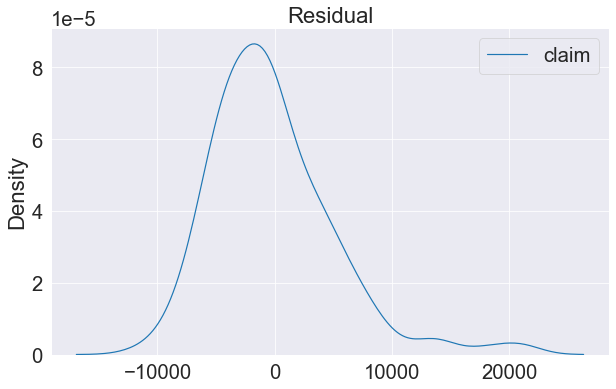

In [164]:
sns.kdeplot(residual)
plt.title('Residual');

In [165]:
residual.skew()

claim    1.272454
dtype: float64

### 4. Homoscedasticity

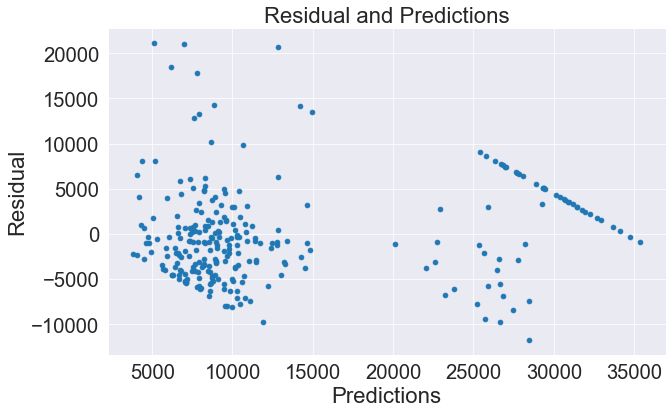

In [166]:
plt.scatter(y_pred,residual)
plt.xlabel('Predictions')
plt.ylabel('Residual')
plt.title('Residual and Predictions');

### 5. Autocorrelation of Residuals

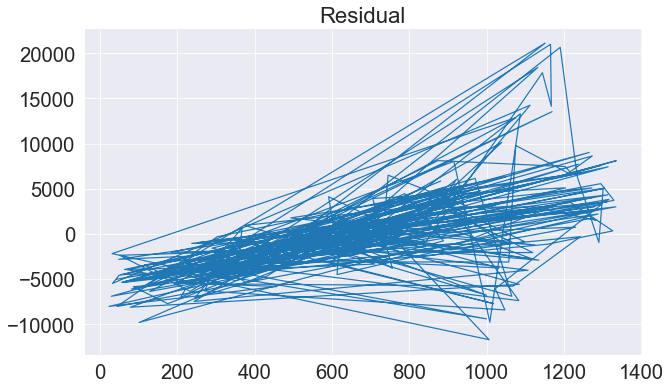

In [167]:
plt.plot(residual)
plt.title('Residual');

**Observation**
- We observed that some assumptions are not fulfilling the requirements of linear Regression so we will see result may be affect by linear Regression.  

### Feature Selection

In [168]:
df = df[['age','bmi', 'bloodpressure', 'diabetic','smoker','claim']]

In [169]:
X = df.drop(columns=['claim'])
y = df[['claim']]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
numeric_cols = [0,1,2]
categorical_cols = [3,4]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('log_transformer', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('linearregression', LinearRegression())
])



In [171]:
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Model Evaluation

In [172]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

### Displaying the evaluation metrics

In [173]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 4122.850497826815
Mean Squared Error: 29466844.982037026
Root Mean Squared Error: 5428.337220736846
R-squared: 0.7309694050315612


### Model Optimization By RandomSearch and GridSearch

In [174]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [175]:
X = df.drop(columns=['claim'])
y = df[['claim']]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [176]:
numeric_cols = [0,1,2]
categorical_cols = [3,4]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('log_transformer', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse=False,drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])



In [177]:
x_train = pipeline.fit_transform(x_train)

x_test = pipeline.transform(x_test)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [178]:
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)
linear_reg_predictions = linear_reg.predict(x_test)
linear_reg_mae = mean_absolute_error(y_test, linear_reg_predictions)
print("Linear Regression Mean Absolute Error:", linear_reg_mae)

Linear Regression Mean Absolute Error: 4122.850497826812


### Ridge Regression

In [179]:
ridge = Ridge()
ridge_parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 0.01 ,0.001,0.0001,1, 1, 1.5,  5, 10, 20, 30, 35, 40, 45, 50, 55, 100]}

ridge_regressor_grid = GridSearchCV(ridge, ridge_parameters, scoring='neg_mean_squared_error', cv=5)
ridge_regressor_random = RandomizedSearchCV(ridge, ridge_parameters, scoring='neg_mean_squared_error', n_iter=10, cv=5, random_state=42)

ridge_regressor_grid.fit(x_train, y_train)
ridge_regressor_random.fit(x_train, y_train)

ridge_grid_predictions = ridge_regressor_grid.best_estimator_.predict(x_test)
ridge_random_predictions = ridge_regressor_random.best_estimator_.predict(x_test)

ridge_grid_mae = mean_absolute_error(y_test, ridge_grid_predictions)
ridge_random_mae = mean_absolute_error(y_test, ridge_random_predictions)



In [180]:
print("Ridge Regression Grid Search Mean Absolute Error:", ridge_grid_mae)
print("Ridge Regression Random Search Mean Absolute Error:", ridge_random_mae)


Ridge Regression Grid Search Mean Absolute Error: 4122.953407568387
Ridge Regression Random Search Mean Absolute Error: 4122.953407568387


In [181]:
ridge_regressor_random.best_params_

{'alpha': 0.01}

### Lasso Regression

In [182]:
lasso = Lasso()
lasso_parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100]}
lasso_regressor_grid = GridSearchCV(lasso, lasso_parameters, scoring='neg_mean_squared_error', cv=5)
lasso_regressor_random = RandomizedSearchCV(lasso, lasso_parameters, scoring='neg_mean_squared_error', n_iter=10, cv=5, random_state=42)

lasso_regressor_grid.fit(x_train, y_train)
lasso_regressor_random.fit(x_train, y_train)

lasso_grid_predictions = lasso_regressor_grid.best_estimator_.predict(x_test)
lasso_random_predictions = lasso_regressor_random.best_estimator_.predict(x_test)

lasso_grid_mae = mean_absolute_error(y_test, lasso_grid_predictions)
lasso_random_mae = mean_absolute_error(y_test, lasso_random_predictions)


C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+10, tolerance: 8.713e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.420e+10, tolerance: 8.888e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

In [183]:
print("Lasso Regression Grid Search Mean Absolute Error:", lasso_grid_mae)
print("Lasso Regression Random Search Mean Absolute Error:", lasso_random_mae)

Lasso Regression Grid Search Mean Absolute Error: 4177.468766792938
Lasso Regression Random Search Mean Absolute Error: 4177.468766792938


### ElasticNet Regression

In [184]:
elasticnet = ElasticNet()
elasticnet_parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55, 100],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
elasticnet_regressor_grid = GridSearchCV(elasticnet, elasticnet_parameters, scoring='neg_mean_squared_error', cv=5)
elasticnet_regressor_random = RandomizedSearchCV(elasticnet, elasticnet_parameters, scoring='neg_mean_squared_error', n_iter=10, cv=5, random_state=42)

elasticnet_regressor_grid.fit(x_train, y_train)
elasticnet_regressor_random.fit(x_train, y_train)

elasticnet_grid_predictions = elasticnet_regressor_grid.best_estimator_.predict(x_test)
elasticnet_random_predictions = elasticnet_regressor_random.best_estimator_.predict(x_test)

elasticnet_grid_mae = mean_absolute_error(y_test, elasticnet_grid_predictions)
elasticnet_random_mae = mean_absolute_error(y_test, elasticnet_random_predictions)


C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.443e+10, tolerance: 8.713e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.424e+10, tolerance: 8.888e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

In [185]:
print("ElasticNet Regression Grid Search Mean Absolute Error:", elasticnet_grid_mae)
print("ElasticNet Regression Random Search Mean Absolute Error:", elasticnet_random_mae)

ElasticNet Regression Grid Search Mean Absolute Error: 4122.850597121631
ElasticNet Regression Random Search Mean Absolute Error: 4122.850597121631


<h3> Choose the best model based on Mean Squared Error </h3><br></br>

In [186]:

best_model = min([
    ("Linear Regression", linear_reg_mae),
    ("Ridge Regression (Grid Search)", ridge_grid_mae),
    ("Ridge Regression (Random Search)", ridge_random_mae),
    ("Lasso Regression (Grid Search)", lasso_grid_mae),
    ("Lasso Regression (Random Search)", lasso_random_mae),
    ("ElasticNet Regression (Grid Search)", elasticnet_grid_mae),
    ("ElasticNet Regression (Random Search)", elasticnet_random_mae)
], key=lambda x: x[1])

print(f"\nBest Model: {best_model[0]}")
print(f"Best Model Mean Absolute Error: {best_model[1]}")




Best Model: Linear Regression
Best Model Mean Absolute Error: 4122.850497826812


**Observation**
- Results are not very good with these algorithims so now will apply some other algorithims and techniques to improve accuracy

In [187]:
dt = DecisionTreeRegressor()
knn = KNeighborsRegressor()
rf = RandomForestRegressor()
gb = GradientBoostingRegressor()
svr = SVR()

In [188]:
dt.fit(x_train,y_train)
knn.fit(x_train,y_train)
rf.fit(x_train,y_train)
gb.fit(x_train,y_train)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11404\964659536.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(x_train,y_train)
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor()

In [189]:
y_pred_dt = dt.predict(x_test)
y_pred_knn = knn.predict(x_test)
y_pred_rf = rf.predict(x_test)
y_pred_gb = gb.predict(x_test)

In [190]:
print("R^2 score for DT",r2_score(y_test,y_pred_dt))
print("R^2 score for KNN",r2_score(y_test,y_pred_knn))
print("R^2 score for RF",r2_score(y_test,y_pred_rf))
print("R^2 score for GBoosting",r2_score(y_test,y_pred_gb))

R^2 score for DT 0.5406667065750118
R^2 score for KNN 0.6921709087308603
R^2 score for RF 0.762981666752568
R^2 score for GBoosting 0.8061337129907721


### Ensemble Learning Techniques
- Voting
- Boosting
- Bagging

<h2 align='center'> Voting Ensemble</h2>

In [191]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

In [192]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
svr = SVR()

In [193]:
estimators = [('lr',lr),('dt',dt),('svr',svr)]

In [194]:
from sklearn.ensemble import VotingRegressor

In [195]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr,x_train,y_train,scoring='r2',cv=10)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_voting.py:597: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_voting.py:597: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_voting.py:597: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_voting.py:597: DataConversionWarning: A column-vector y was pass

In [196]:
print("Voting Regressor",np.round(np.mean(scores),2))

Voting Regressor 0.59


<h2 align='center'> Bagging Ensemble <h2/>

In [197]:
from sklearn.ensemble import BaggingRegressor

bag_regressor = BaggingRegressor(random_state=1)
bag_regressor.fit(x_train, y_train)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_bagging.py:508: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


BaggingRegressor(random_state=1)

In [198]:
Y_preds = bag_regressor.predict(x_test)
print('Training Coefficient of R^2 : %.3f'%bag_regressor.score(x_train, y_train))
print('Test Coefficient of R^2 : %.3f'%bag_regressor.score(x_test, y_test))

Training Coefficient of R^2 : 0.943
Test Coefficient of R^2 : 0.757


In [199]:
regressor = GradientBoostingRegressor()

In [200]:
regressor.fit(x_train, y_train)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor()

In [201]:
y_pred = regressor.predict(x_test)

### Model Evaluation

In [202]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

### Displaying the evaluation metrics

In [203]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2-squared:", r2)

Mean Absolute Error: 3281.2741852349477
Mean Squared Error: 21237231.752269097
Root Mean Squared Error: 4608.3871096370685
R2-squared: 0.8061052991157179


**Observation**
- As GradientBoostingRegressor has given Best results so we will deploy aour model with GradientBoostingRegressor

### Feature Enginering PipeLine

In [204]:
numeric_cols = [0,1,2]
categorical_cols = [3,4]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('log_transformer', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('BaggingRegressor',GradientBoostingRegressor())
    
])


In [205]:
X = df.drop(columns=['claim'])
y = df[['claim']]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [206]:
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
